# Plots 

In [1]:
import os
import json
import pandas as pd
import numpy as np
import math
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from plot_v2 import *

In [2]:
def load_ndjson(file):
    output = []
    with open(file, "r") as f:  
        for line in f:
            line = line.strip()  
            if line:  
                try:
                    single_cell = json.loads(line)
                    output.append(single_cell)
                except json.JSONDecodeError as e:
                    print(f"Error decoding JSON from line: {e}")
    return output
def load_json(file):
    with open(file, "r") as f:
        try:
            data = json.load(f)
            return data
        except json.JSONDecodeError as e:
            print(f"Error decoding JSON from file: {e}")
            return None
        
def create_np_array_from_tissue_df(tissue_df):
    """
    Converts the output of the provided loop into a 4 x n NumPy array.

    Args:
        tissue_df: A dictionary where keys are tissue names (t) and values
                   are lists of dictionaries, each containing a 'match_scTab' key.

    Returns:
        A NumPy array of shape (m, n), where m is number of dfs,` n is the number of tissues
    """

    num_tissues = len(tissue_df)
    num_dfs = len(tissue_df[list(tissue_df.keys())[0]])
    result_array = np.zeros((num_dfs, num_tissues))

    for i, (t, df) in enumerate(tissue_df.items()):
        for j in range(num_dfs):
            result_array[j, i] = np.mean(df[j]['match_scTab'])

    return result_array


def macro_f1_from_df(df: pd.DataFrame) -> float:
    """
    从 Pandas DataFrame 计算 macro_f1 分数。

    DataFrame 必须包含以下列:
    - 'ground_truth_label': 实例的真实标签。
    - 'predicted_label': 模型预测的标签。
    - 'match_scTab': 一个布尔列 (True/False)，指示预测是否被认为是正确的
                     (例如，根据 scTab 规则，精确匹配或预测是真实标签的子节点等)。

    参数:
        df (pd.DataFrame): 输入的 DataFrame。

    返回:
        float: 计算得到的 macro_f1 分数。
    """
    required_cols = ['ground_truth_label', 'predicted_label', 'match_scTab']
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"DataFrame 必须包含列: '{col}'")

    # 复制 DataFrame 以避免修改原始数据
    df_eval = df.copy()
    if df_eval.shape[0]==0: return np.float64('nan')

    # 确保 'match_scTab' 列是布尔类型，并将NA视作False (不匹配)
    if df_eval['match_scTab'].isnull().any():
        df_eval['match_scTab'] = df_eval['match_scTab'].fillna(False)
    df_eval['match_scTab'] = df_eval['match_scTab'].astype(bool)

    # 获取所有唯一的真实标签，用于计算每个类别的指标
    # 过滤掉空字符串或纯空格的标签，以及NaN值
    gt_labels_present = df_eval['ground_truth_label'].dropna().unique()
    gt_labels_present = [str(label) for label in gt_labels_present if str(label).strip() != ""]
    gt_labels_present = sorted(list(set(gt_labels_present))) # Ensure uniqueness and consistent order

    if not gt_labels_present:
        return 0.0

    f1_scores = []

    for label_class in gt_labels_present:
        # True Positives (TP): 真实标签是当前类别，并且预测是正确的
        tp = ((df_eval['ground_truth_label'] == label_class) & (df_eval['match_scTab'] == True)).sum()
        
        # False Negatives (FN): 真实标签是当前类别，但预测是错误的
        fn = ((df_eval['ground_truth_label'] == label_class) & (df_eval['match_scTab'] == False)).sum()
        
        # False Positives (FP): 预测标签是当前类别，但预测是错误的
        fp = ((df_eval['predicted_label'] == label_class) & (df_eval['match_scTab'] == False)).sum()

        precision = 0.0
        if (tp + fp) > 0:
            precision = tp / (tp + fp)
        
        recall = 0.0
        if (tp + fn) > 0:
            recall = tp / (tp + fn)
        
        f1 = 0.0
        if (precision + recall) > 0:
            f1 = 2 * (precision * recall) / (precision + recall)
        
        f1_scores.append(f1)

    if not f1_scores:
        macro_f1 = 0.0
    else:
        macro_f1 = sum(f1_scores) / len(f1_scores)
        
    return macro_f1
def f1_np_array_from_tissue_df(tissue_df):
    """
    """

    num_tissues = len(tissue_df)
    num_dfs = len(tissue_df[list(tissue_df.keys())[0]])
    result_array = np.zeros((num_dfs, num_tissues))

    for i, (t, df) in enumerate(tissue_df.items()):
        for j in range(num_dfs):
            f = macro_f1_from_df(df[j])
            result_array[j, i] = f


    return result_array


In [3]:
def split_by_matching(ground_truth_children_dict, model_labels):
    '''
    Find ground truth cells that are in the model labels and not in the model labels
    '''
    matched_celltypes = []
    unmatched_celltypes = []
    for cell, children in ground_truth_children_dict.items():
        if set(children).intersection(model_labels):
            matched_celltypes.append(cell)
        else: unmatched_celltypes.append(cell)
    return {'matched':matched_celltypes, 'unmatched':unmatched_celltypes}

def split_dataset(df_list, index_dict, df_col):
    ''' 
    split df_list to separate lists according to df_col and index_dict
    '''
    df_dict = {}
    for k,v in index_dict.items():
        df_dict[k] = [df[df[df_col].isin(v)] for df in df_list]
    return df_dict

def add_in_label(
    df_list,
    str_list,
    name_col: str = "name",
    new_col: str = "in_label",
    in_place: bool = True,
):
    """
    Modify the df list, add a col to indicate if ground true is in/off label
    Add a boolean column `new_col` to every DataFrame in `df_list`,
    indicating whether the value in `name_col` is contained in `str_list`.

    Parameters
    ----------
    df_list : list[pd.DataFrame]
        A list of DataFrames that all contain the column `name_col`.
    str_list : Iterable[str]
        Collection of strings used for membership testing.
    name_col : str, default "name"
        Column to be checked against `str_list`.
    new_col : str, default "in_label"
        Name of the new column to be created.
    in_place : bool, default True
        • True  → modify each DataFrame in place and return the *same* list.  
        • False → work on copies and return a *new* list.

    Returns
    -------
    list[pd.DataFrame]
        The list of modified DataFrames (original objects if `in_place=True`).

    Notes
    -----
    * Missing values (`NaN`, `pd.NA`, `None`) are preserved as missing.
    * Converting `str_list` to a `set` speeds up membership checks.
    """
    string_set = set(str_list)

    def _process_df(df: pd.DataFrame) -> pd.DataFrame:
        # Vectorised test for membership
        hits = df[name_col].isin(string_set)

        # Preserve missing values
        new_series = np.where(df[name_col].isna(), pd.NA, hits)

        df[new_col] = new_series
        return df

    if in_place:
        for d in df_list:
            _process_df(d)
        return df_list
    else:
        return [_process_df(d.copy(deep=True)) for d in df_list]

In [4]:
# load cell type label information for sctab, scgpt and ground truth
# get mapped results for scTab labels
sctab_results = load_ndjson('/cristealab/xiwang/DSR1_Preprint/Outputs/Celltype_alignment/scTab_labels/step2_matched.ndjson')
sctab_celltypes_mapped = [result['predicted_label_clean'] for result in sctab_results]
# get mapped results for scgpt labels
scgpt_results = load_ndjson('/cristealab/xiwang/DSR1_Preprint/Outputs/Celltype_alignment/scGPT_labels/step2_matched.ndjson')
scgpt_celltypes_mapped = [result['predicted_label_clean'] for result in scgpt_results]
# get each ground truth celltype's all children
ground_truth_children = load_json('/cristealab/xiwang/DSR1_Preprint/Outputs/Celltype_alignment/groundtruth_labels/results.json')
ground_truth_children_dict = {
    cell["ground_truth_label"]:cell["ground_truth_children"] for cell in ground_truth_children['cells']
} 
for i in range(len(ground_truth_children['cells'])):
    ground_truth_children_dict[ground_truth_children['cells'][i]["ground_truth_label"]]=ground_truth_children['cells'][i]["ground_truth_children"]


# split ground truth cell types label by in/off sctab
sctab_split = split_by_matching(ground_truth_children_dict, sctab_celltypes_mapped)
# by scgpt
scgpt_split = split_by_matching(ground_truth_children_dict, scgpt_celltypes_mapped)

In [5]:
# load results for 8d and random datasets
file_paths_8d = [
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_8datasets_10k_v2/responses/scTab/results.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_8datasets_10k_v2/responses/scGPT/results.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_8datasets_10k_v2/responses/long_prompt_r1_0528/500genes_scGPTClassifier/results.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_8datasets_10k_v2/responses/long_prompt_r1_0528/500genes_scTabClassifier/results.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_8datasets_10k_v2/responses/long_prompt_r1_0528/500genes/results.csv'
]
file_paths_random = [
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_random_10k_v2/responses/scTab/results.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_random_10k_v2/responses/scGPT/results.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_random_10k_v2/responses/long_prompt_r1_0528/500genes_scTabClassifier/results.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_random_10k_v2/responses/long_prompt_r1_0528/500genes/results.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_random_10k_v2/responses/long_prompt_r1_0528/500genes_scGPTClassifier/results.csv',
]
# cellxgene 8d data
sctab_8d, scgpt_8d, r1_scgpt_cls_8d, r1_sctab_cls_8d, r1_8d = (pd.read_csv(file) for file in file_paths_8d)
# cellxgene random sampled data
sctab_random, scgpt_random, r1_sctab_cls_random, r1_random, r1_scgpt_cls_random = (pd.read_csv(file) for file in file_paths_random)

In [21]:
# models whose performance are evaluated and plotted
models = ['scTab', 'R1 (scGPT Classifier)', 'R1 (scTab Classifier)', 'scGPT', 'R1']

In [7]:
# plot for random dataset
# df list for results in the order of picked models
prediction_df_random = [sctab_random, r1_scgpt_cls_random, r1_sctab_cls_random, scgpt_random, r1_random]

# split ground truth cell types by matching
prediction_df_random_by_sctab = split_dataset(prediction_df_random, sctab_split, 'ground_truth_label')

prediction_df_random_by_scgpt = split_dataset(prediction_df_random, scgpt_split, 'ground_truth_label')


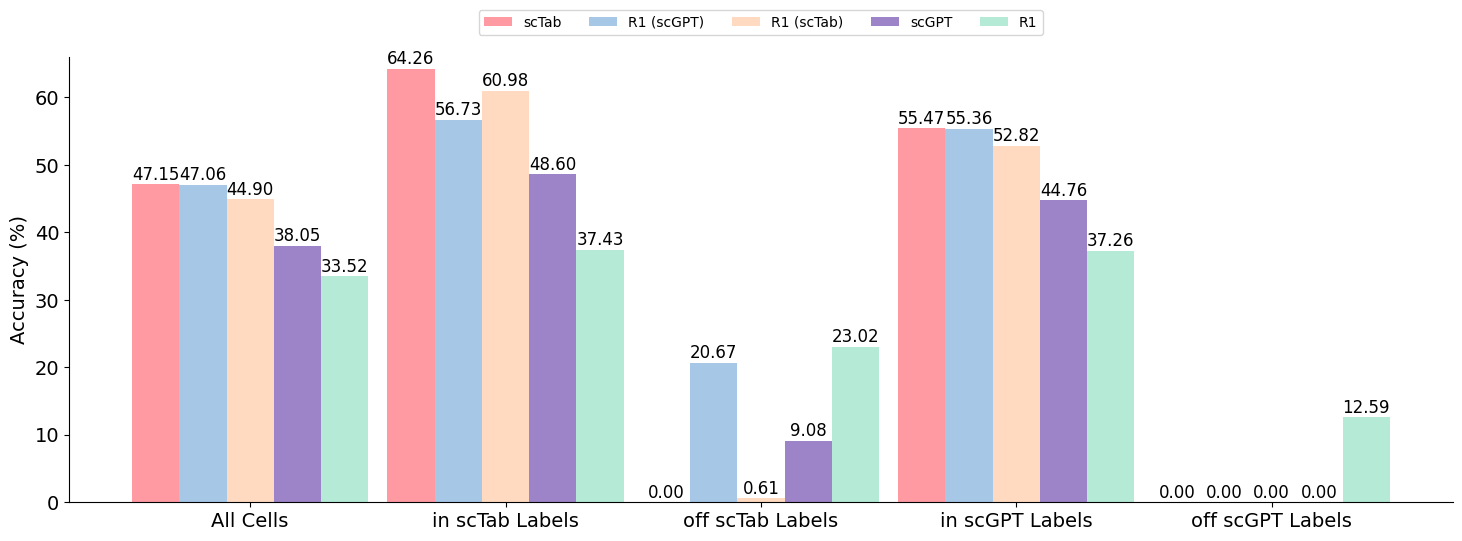

In [ ]:
overall_acc = [float(df.iloc[-4,2]) for df in prediction_df_random]
sctab_acc = create_np_array_from_tissue_df(prediction_df_random_by_sctab)
scgpt_acc = create_np_array_from_tissue_df(prediction_df_random_by_scgpt)
plotter = MetricPlotter(bar_width = 0.5, annotation_digits=2, 
                        y_lim_lower = 0, 
                        # y_lim_upper=100
                        )
plotter.display_axes_borders = 'xy'
plotter.group_gap = 0.2
plotter.text_margin = 0.001
plotter.ncol_legend = 5
plotter.colors = ['#FF9AA2','#A7C7E7','#FFDAC1','#9D84C8','#B5EAD7',]
plotter.bar_fontsize = 12
plotter.x_label_fontsize = 14
plotter.y_label_fontsize=14
plotter.x_tick_fontsize=14
plotter.y_tick_fontsize=14
groups = ['All Cells', 'in scTab Labels','off scTab Labels','in scGPT Labels','off scGPT Labels']
plotter.group_barplot(groups,models,metrics = np.column_stack((overall_acc, sctab_acc, scgpt_acc)), 
             x_label="", y_label="Accuracy", 
             # title="LLMs' Performance for Clusters"
             )
# 1.8 1 6.13

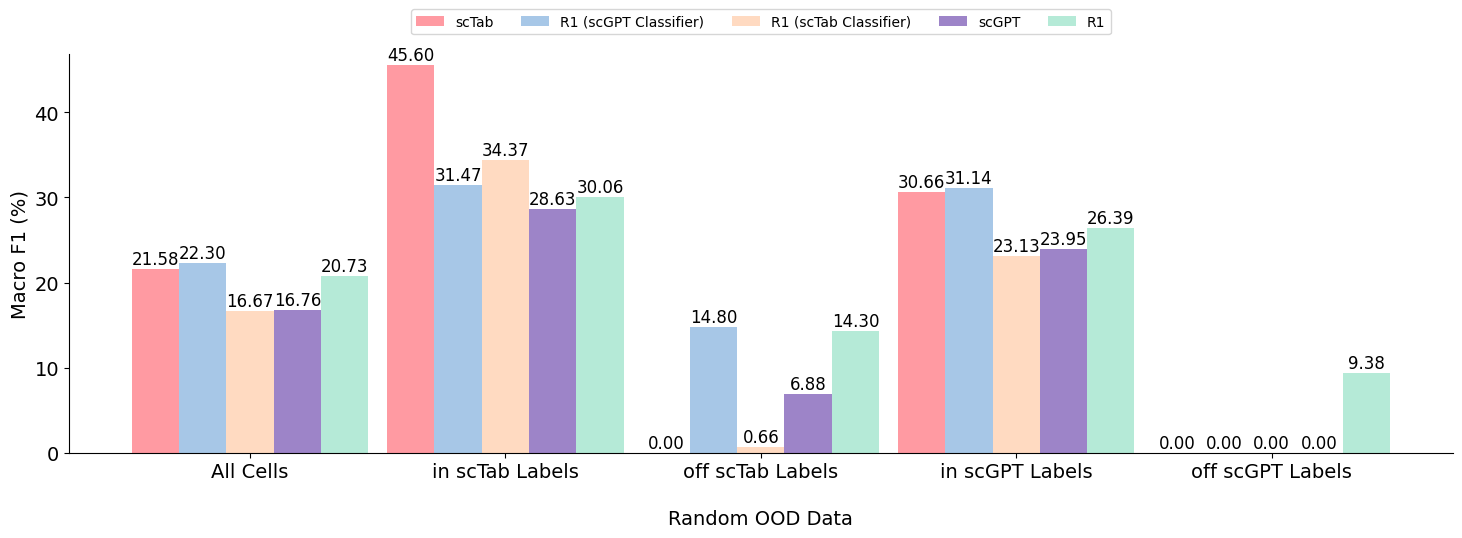

In [ ]:
overall_f1 = [float(df.iloc[-3,2]) for df in prediction_df_random]
sctab_f1 = f1_np_array_from_tissue_df(prediction_df_random_by_sctab)
scgpt_f1 = f1_np_array_from_tissue_df(prediction_df_random_by_scgpt)
plotter = MetricPlotter(bar_width = 0.5, annotation_digits=2, 
                        y_lim_lower = 0, 
                        # y_lim_upper=100
                        )
plotter.display_axes_borders = 'xy'
plotter.group_gap = 0.2
plotter.text_margin = 0.001
plotter.ncol_legend = 5
plotter.colors = ['#FF9AA2','#A7C7E7','#FFDAC1','#9D84C8','#B5EAD7',]
plotter.bar_fontsize = 12
plotter.x_label_fontsize = 14
plotter.y_label_fontsize=14
plotter.x_tick_fontsize=14
plotter.y_tick_fontsize=14
groups = ['All Cells', 'in scTab Labels','off scTab Labels','in scGPT Labels','off scGPT Labels']
plotter.group_barplot(groups,models,metrics = np.column_stack((overall_f1, sctab_f1, scgpt_f1)), 
             x_label="\nRandom OOD Data", y_label="Macro F1", 
             # title="LLMs' Performance for Clusters"
             )
# 1.8 1 7.81

# balanced tissue OOD

In [22]:
# plots for datasets of balanced tissues
# result dfs by order
prediction_df_8d = [sctab_8d, r1_scgpt_cls_8d, r1_sctab_cls_8d, scgpt_8d, r1_8d]
'''# remove unknown
prediction_df_8d = [process_df(df) for df in prediction_df_8d]'''
# add tissue col for tissue split
cells_8d = load_ndjson('/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_8datasets_10k_v2/prompts/prompts_100genes.ndjson')
id_to_tissue = {str(cell['soma_joinid']):cell['tissue'] for cell in cells_8d}
for df in prediction_df_8d:
    df['tissue'] = ''
    df.loc[df['cell'].isin(id_to_tissue), 'tissue'] = df['cell'].map(id_to_tissue)

In [23]:
# split ground truth cell types by matching
# by sctab
prediction_df_8d_by_sctab = split_dataset(prediction_df_8d, sctab_split, 'ground_truth_label')
# by scgpt
prediction_df_8d_by_scgpt = split_dataset(prediction_df_8d, scgpt_split, 'ground_truth_label')

In [11]:
prediction_df_8d[0]

,cell,ground_truth_label,predicted_label,verdict,match_scTab,tissue
0,61989204,retinal bipolar neuron,pericyte,NO_DIRECT_CHILD_RELATION,False,peripheral region of retina
1,61602271,invaginating midget bipolar cell,pericyte,NO_DIRECT_CHILD_RELATION,False,peripheral region of retina
2,61628059,retinal rod cell,retinal cone cell,NO_DIRECT_CHILD_RELATION,False,peripheral region of retina
3,61927017,flat midget bipolar cell,pericyte,NO_DIRECT_CHILD_RELATION,False,peripheral region of retina
4,62239331,flat midget bipolar cell,L2 intratelencephalic projecting glutamatergic...,NO_DIRECT_CHILD_RELATION,False,peripheral region of retina
...,...,...,...,...,...,...
10001,EVALUATION_METRICS,NUM_TRUE,2017,NaN,NaN,
10002,EVALUATION_METRICS,ACCURACY,0.2017,NaN,NaN,
10003,EVALUATION_METRICS,MACRO_F1,0.1597,NaN,NaN,
10004,EVALUATION_METRICS,WEIGHTED_F1,0.1874,NaN,NaN,


In [12]:
overall_acc = [float(df.iloc[-5,2])/(10000-382) for df in prediction_df_8d] # based on non-missing cells
sctab_acc = create_np_array_from_tissue_df(prediction_df_8d_by_sctab)
scgpt_acc = create_np_array_from_tissue_df(prediction_df_8d_by_scgpt)

In [13]:
overall_acc

[0.20971095861925557,
 0.37710542732376795,
 0.23747140777708464,
 0.21667706383863589,
 0.28176336036598043]

In [20]:
np.column_stack((sctab_acc, scgpt_acc)).shape

(5, 4)

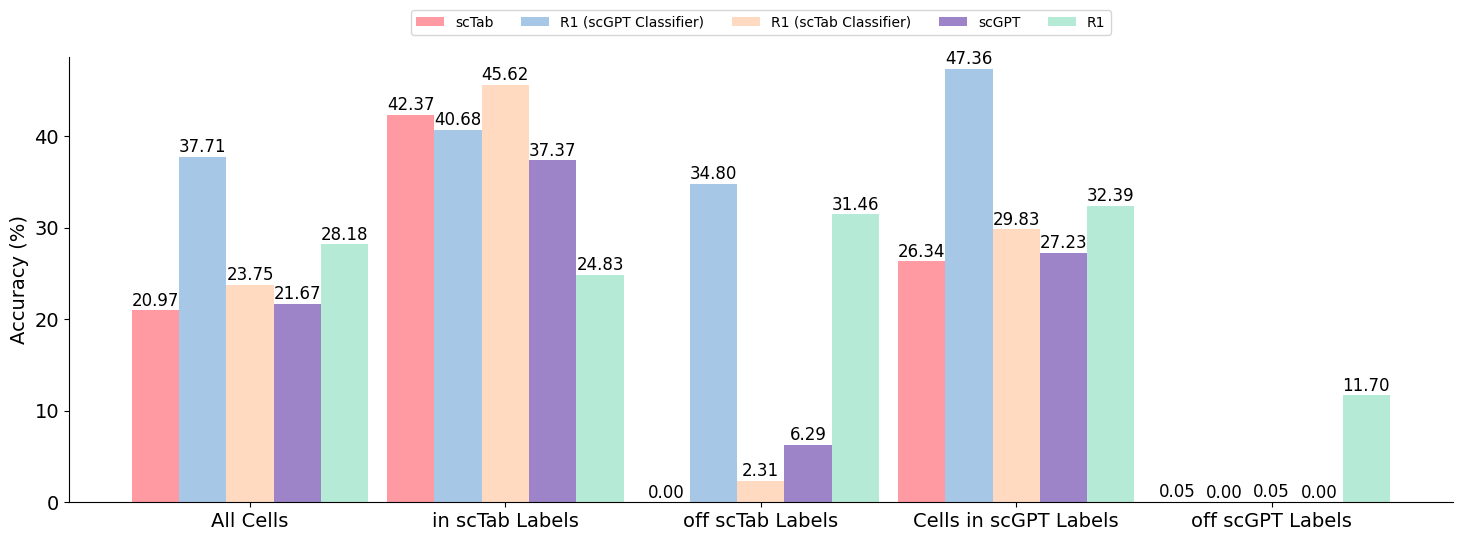

In [14]:
overall_acc = [float(df.iloc[-5,2])/(10000-382) for df in prediction_df_8d] # based on non-missing cells
sctab_acc = create_np_array_from_tissue_df(prediction_df_8d_by_sctab)
scgpt_acc = create_np_array_from_tissue_df(prediction_df_8d_by_scgpt)
plotter = MetricPlotter(bar_width = 0.5, annotation_digits=2, 
                        y_lim_lower = 0, 
                        # y_lim_upper=100
                        )
plotter.display_axes_borders = 'xy'
plotter.group_gap = 0.2
plotter.text_margin = 0.001
plotter.ncol_legend = 5
plotter.colors = ['#FF9AA2','#A7C7E7','#FFDAC1','#9D84C8','#B5EAD7',]
plotter.bar_fontsize = 12
plotter.x_label_fontsize = 14
plotter.y_label_fontsize=14
plotter.x_tick_fontsize=14
plotter.y_tick_fontsize=14
groups = ['All Cells', 'in scTab Labels','off scTab Labels','Cells in scGPT Labels','off scGPT Labels']
plotter.group_barplot(groups,models,metrics = np.column_stack((overall_acc, sctab_acc, scgpt_acc)), 
             x_label="", y_label="Accuracy", 
             # title="LLMs' Performance for Clusters"
             )
# 1.25 0.19 3.63

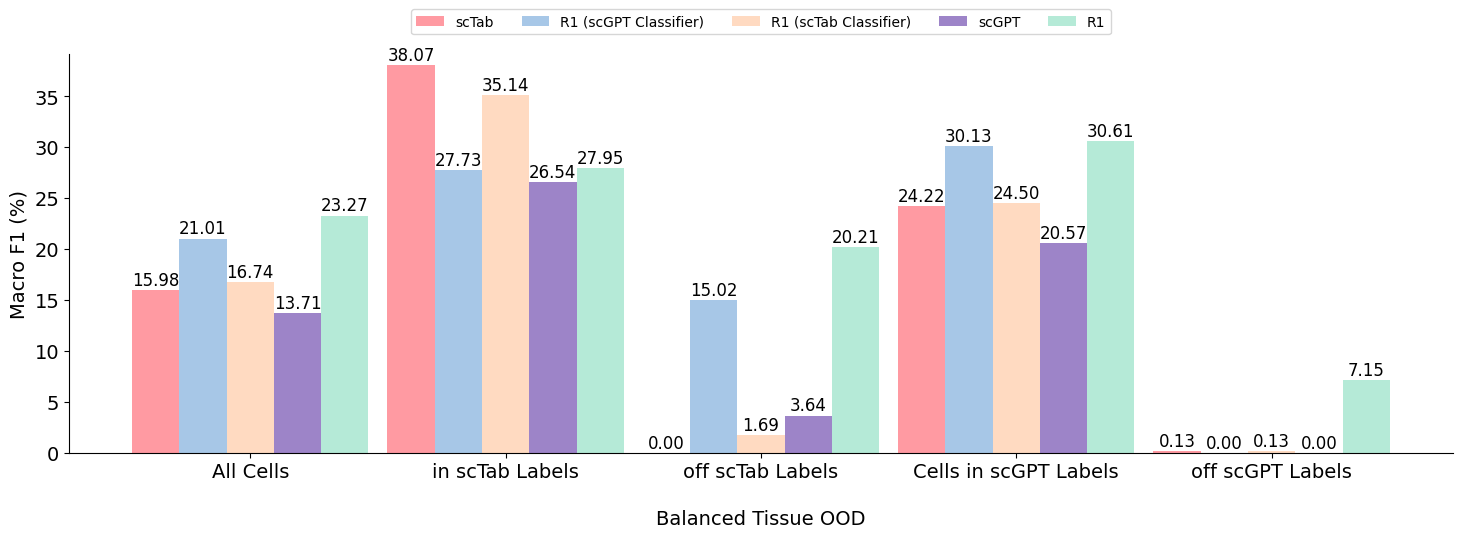

In [24]:
# remove missing of 8d for f1
prediction_df_8d = [df[:10000] for df in prediction_df_8d]; prediction_df_8d = [df.dropna(subset=['ground_truth_label']) for df in prediction_df_8d]
overall_f1 = [macro_f1_from_df(df) for df in prediction_df_8d]
sctab_f1 = f1_np_array_from_tissue_df(prediction_df_8d_by_sctab)
scgpt_f1 = f1_np_array_from_tissue_df(prediction_df_8d_by_scgpt)
plotter = MetricPlotter(bar_width = 0.5, annotation_digits=2, 
                        y_lim_lower = 0, 
                        # y_lim_upper=100
                        )
plotter.display_axes_borders = 'xy'
plotter.group_gap = 0.2
plotter.text_margin = 0.001
plotter.ncol_legend = 5
plotter.colors = ['#FF9AA2','#A7C7E7','#FFDAC1','#9D84C8','#B5EAD7',]
plotter.bar_fontsize = 12
plotter.x_label_fontsize = 14
plotter.y_label_fontsize=14
plotter.x_tick_fontsize=14
plotter.y_tick_fontsize=14
groups = ['All Cells', 'in scTab Labels','off scTab Labels','Cells in scGPT Labels','off scGPT Labels']
plotter.group_barplot(groups,models,metrics = np.column_stack((overall_f1, sctab_f1, scgpt_f1)), 
             x_label="\nBalanced Tissue OOD", y_label="Macro F1", 
             # title="LLMs' Performance for Clusters"
             )
# 1.25 0.19 4.78

In [16]:
# split by tissues in all cells
# tissues = set([cell['tissue'] for cell in cells_8d])
tissues= ['blood', 'pancreas', 'breast', 'lung', 'cerebellum', 'trachea', 'kidney', 'peripheral region of retina']
tissue_index = {t:[t] for t in tissues}
prediction_df_8d_by_tissue = split_dataset(prediction_df_8d, tissue_index, 'tissue')
tissue_acc = create_np_array_from_tissue_df(prediction_df_8d_by_tissue)
tissue_f1 = f1_np_array_from_tissue_df(prediction_df_8d_by_tissue)

# split by tissues in scTab labels
prediction_df_8d_in_sctab_by_tissue = split_dataset(prediction_df_8d_by_sctab['matched'], tissue_index, 'tissue')
# split by tissues off scTab labels
prediction_df_8d_off_sctab_by_tissue = split_dataset(prediction_df_8d_by_sctab['unmatched'], tissue_index, 'tissue')


In [17]:
tissue_index

{'blood': ['blood'],
 'pancreas': ['pancreas'],
 'breast': ['breast'],
 'lung': ['lung'],
 'cerebellum': ['cerebellum'],
 'trachea': ['trachea'],
 'kidney': ['kidney'],
 'peripheral region of retina': ['peripheral region of retina']}

In [17]:
# number of cells for each tissue
for tissue, dfs in prediction_df_8d_by_tissue.items():
    print(tissue, dfs[0].shape[0])

blood 1250
pancreas 1250
breast 1250
lung 868
cerebellum 1250
trachea 1250
kidney 1250
peripheral region of retina 1250


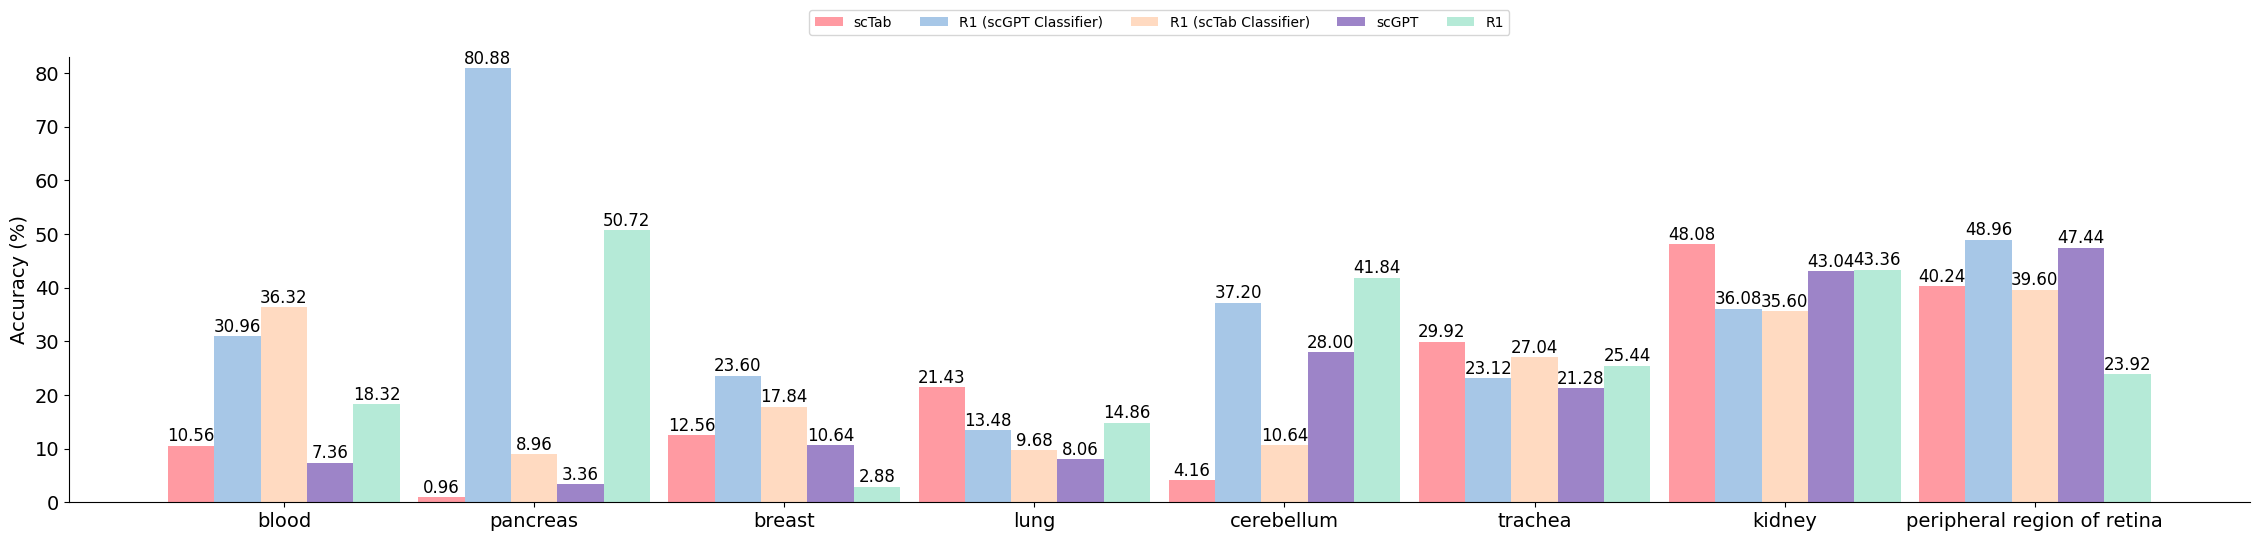

In [18]:
plotter.group_barplot(tissue_index.keys(),models,metrics = tissue_acc, 
             x_label="", y_label="Accuracy"
             )

In [19]:
def plot_heatmap(
    data,
    row_names=None,
    col_names=None,
    title: str = "Heatmap",
    xlabel: str = "Columns",
    ylabel: str = "Rows",
    cmap = "viridis",
    annot = True,
    fmt: str = ".2f",
    linewidths: float = 0.5,
    linecolor: str = "lightgray",
    cbar: bool = False,
    figsize = (10, 8),
    xtick_rotation = 45,
    ax=None,
    vmin = None,
    vmax = None,
    nan_color: str = "grey",
    annot_fontsize = None,
    xtick_fontsize = 16,
    ytick_fontsize = 16,
    **kwargs,
):
    """
    Draw a heatmap for an *m × n* data matrix with percentage annotations.
    
    Parameters
    ----------
    data : array-like | pandas.DataFrame
        Matrix to plot (shape m × n).
    row_names, col_names : list-like | None
        Row/column labels if *data* is not a DataFrame.
    title, xlabel, ylabel : str
        Figure and axis titles.
    cmap : str | matplotlib.colors.Colormap
        Colormap for the heatmap.
    annot : bool | array-like
        If ``True``, display each cell’s numeric value (converted to %).
        If array-like, use it directly.
    fmt : str
        ``str.format`` specification for annotations (after ×100).
    linewidths, linecolor : float | str
        Grid line width / colour.
    cbar : bool
        Whether to draw a colour bar.
    figsize : (width, height)
        Figure size in inches (ignored if *ax* is supplied).
    xtick_rotation : int | float
        Rotation applied to x-tick labels.
    ax : matplotlib.axes.Axes | None
        Existing axes to draw on; create new ones if ``None``.
    vmin, vmax : float | None
        Fixed colour scale limits; ``None`` lets seaborn pick them.
    nan_color : str
        Colour for ``NaN`` cells.
    annot_fontsize, xtick_fontsize, ytick_fontsize : int | float | None
        Font sizes for annotations and tick labels.
    **kwargs
        Extra keyword arguments passed straight to ``seaborn.heatmap``.

    Returns
    -------
    matplotlib.axes.Axes
        The axes containing the heatmap.
    """
    # --------------------------------------------------------------------- #
    # 1. Convert *data* to DataFrame so row/col labels are easy to manage   #
    # --------------------------------------------------------------------- #
    if isinstance(data, pd.DataFrame):
        plot_data = data.copy()
        _row_names = data.index.tolist() if row_names is None else row_names
        _col_names = data.columns.tolist() if col_names is None else col_names
    else:
        plot_data = pd.DataFrame(data, index=row_names, columns=col_names)
        _row_names = plot_data.index.tolist()
        _col_names = plot_data.columns.tolist()

    # --------------------------------------------------------------------- #
    # 2. Create (or re-use) axes                                            #
    # --------------------------------------------------------------------- #
    if ax is None:
        fig, current_ax = plt.subplots(figsize=figsize)
    else:
        current_ax = ax
        fig = current_ax.figure

    # Copy colormap so we can safely mutate the “bad” colour for NaNs
    current_cmap = plt.cm.get_cmap(cmap)
    custom_cmap = current_cmap.copy()
    custom_cmap.set_bad(color=nan_color)

    # --------------------------------------------------------------------- #
    # 3. Prepare annotation keyword args                                    #
    # --------------------------------------------------------------------- #
    current_annot_kws = kwargs.pop("annot_kws", {}).copy()
    if annot_fontsize is not None:
        current_annot_kws["fontsize"] = annot_fontsize

    # --------------------------------------------------------------------- #
    # 4. Automatically turn values into percentages if annot is True        #
    # --------------------------------------------------------------------- #
    if isinstance(annot, bool):
        annot_to_use = plot_data * 100 if annot else False
    else:  # user supplied custom annotations → do not alter
        annot_to_use = annot

    # --------------------------------------------------------------------- #
    # 5. Draw the heatmap                                                   #
    # --------------------------------------------------------------------- #
    sns.heatmap(
        plot_data,
        annot=annot_to_use,
        fmt=fmt,
        cmap=custom_cmap,
        linewidths=linewidths,
        linecolor=linecolor,
        cbar=cbar,
        ax=current_ax,
        xticklabels=True,
        yticklabels=True,
        vmin=vmin,
        vmax=vmax,
        annot_kws=current_annot_kws if current_annot_kws else None,
        **kwargs,
    )

    # --------------------------------------------------------------------- #
    # 6. Axis-level aesthetics                                              #
    # --------------------------------------------------------------------- #
    current_ax.set_title(title, fontsize=14, fontweight="bold")
    current_ax.set_xlabel(xlabel, fontsize=20)
    current_ax.set_ylabel(ylabel, fontsize=20)

    current_ax.set_xticks(np.arange(len(_col_names)) + 0.5)
    current_ax.set_yticks(np.arange(len(_row_names)) + 0.5)
    current_ax.set_xticklabels(_col_names)
    current_ax.set_yticklabels(_row_names)

    # Tick-label font sizes
    if xtick_fontsize is not None:
        plt.setp(current_ax.get_xticklabels(), fontsize=xtick_fontsize)
    if ytick_fontsize is not None:
        plt.setp(current_ax.get_yticklabels(), fontsize=ytick_fontsize)

    # Tick-label rotation
    if xtick_rotation not in (None, 0):
        plt.setp(
            current_ax.get_xticklabels(),
            rotation=xtick_rotation,
            ha="right",
            rotation_mode="anchor",
        )
    elif xtick_rotation == 0:
        plt.setp(current_ax.get_xticklabels(), rotation=0, ha="center")

    plt.setp(current_ax.get_yticklabels(), rotation=0)

    # Tight layout for new figures (won’t interfere if *ax* was provided)
    if ax is None:
        try:
            fig.tight_layout()
        except (ValueError, RuntimeError):
            # Occasional failure with very small figures
            print("Warning: tight_layout failed; elements may overlap.")

    return current_ax


/tmp/ipykernel_3523988/505786259.py:89: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  current_cmap = plt.cm.get_cmap(cmap)


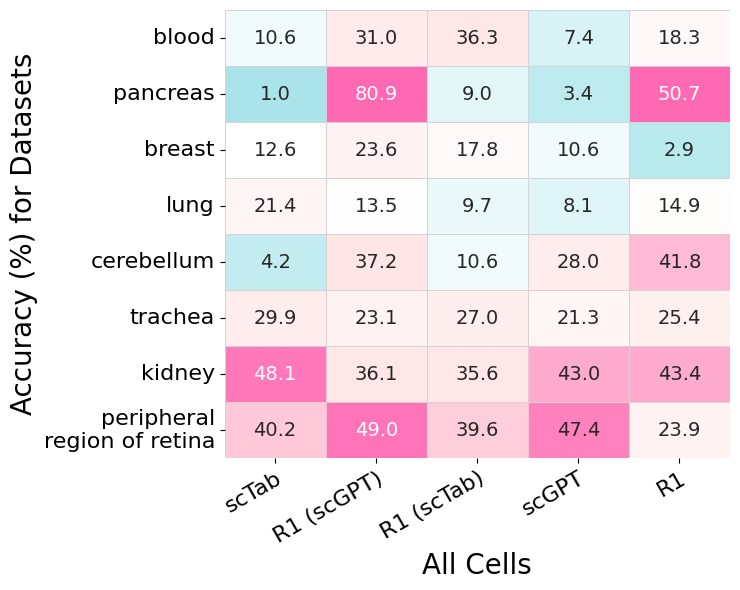

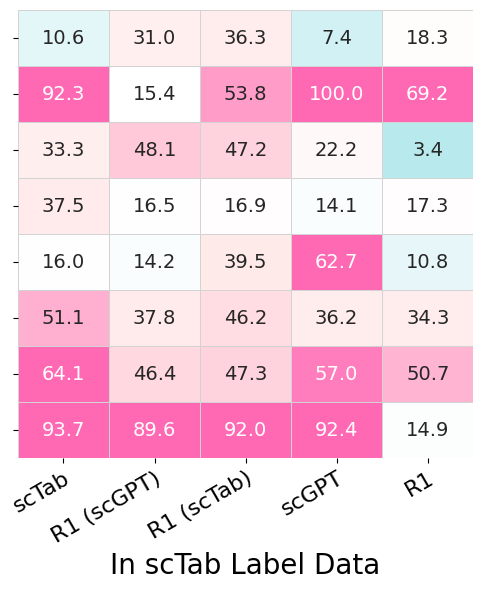

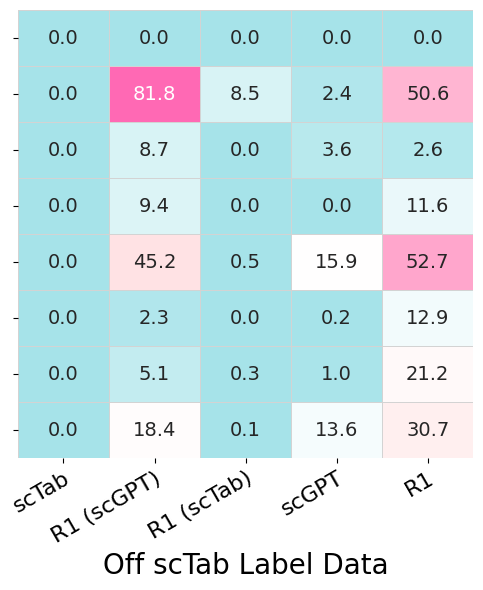

In [20]:
from matplotlib.colors import LinearSegmentedColormap # Import this
# Use hex codes or color names recognized by matplotlib
colors = ["#A6E3E9","#FFFFFF",'#FFF0F0','#FFE6E6',"#FF69B4"]
n_bins = 100 # Number of discrete color steps
cmap_name = "YlOrPi_custom"
my_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

tissue_names = [tissue for tissue in tissue_index.keys()]
for i in range(len(tissue_names)): 
    if tissue_names[i] == 'peripheral region of retina':
        tissue_names[i] = 'peripheral\nregion of retina'
models = ['scTab', 'R1 (scGPT)', 'R1 (scTab)', 'scGPT', 'R1']

ax1 = plot_heatmap(
    tissue_acc.T,
    row_names=tissue_names,
    col_names=models,
    title="",
    xlabel="All Cells",
    ylabel="Accuracy (%) for Datasets",
    cmap=my_cmap,      # Diverging colormap
    fmt=".1f",            # One decimal place
    figsize=(7.5, 6),       # Custom size
    xtick_rotation=30,
    vmin=0,
    vmax=0.5, annot_fontsize = 14
)
plt.show()

ax1 = plot_heatmap(
    create_np_array_from_tissue_df(prediction_df_8d_in_sctab_by_tissue).T,
    row_names=['']*8,
    col_names=models,
    title="",
    xlabel="In scTab Label Data",
    ylabel="",
    cmap=my_cmap,      # Diverging colormap
    fmt=".1f",            # One decimal place
    figsize=(5, 6),       # Custom size
    xtick_rotation=30,
    vmin=0,
    vmax=0.6, annot_fontsize = 14
)
plt.show()

ax1 = plot_heatmap(
    create_np_array_from_tissue_df(prediction_df_8d_off_sctab_by_tissue).T,
    row_names=['']*8,
    col_names=models,
    title="",
    xlabel="Off scTab Label Data",
    ylabel="",
    cmap=my_cmap,      # Diverging colormap
    fmt=".1f",            # One decimal place
    figsize=(5, 6),       # Custom size
    xtick_rotation=30,
    vmin=0,
    vmax=0.6, annot_fontsize = 14
)
plt.show()
# 1.25 3.87 3.68
# 1.25 5.42 3.68
# 1.25 6.42 3.68

/tmp/ipykernel_3523988/505786259.py:89: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  current_cmap = plt.cm.get_cmap(cmap)


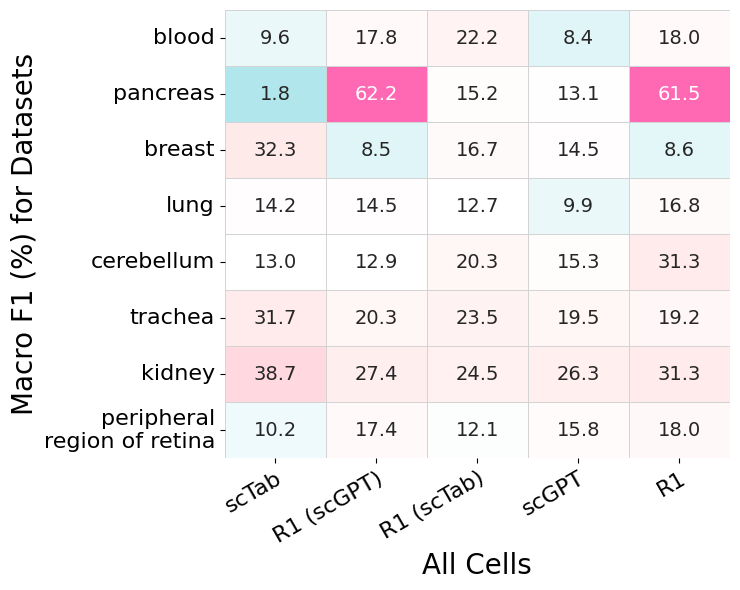

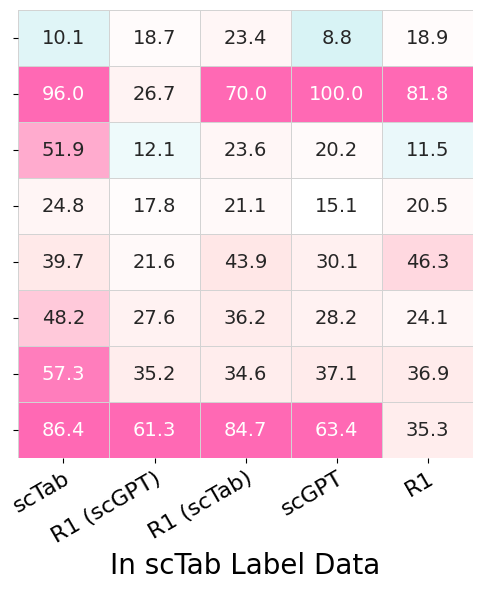

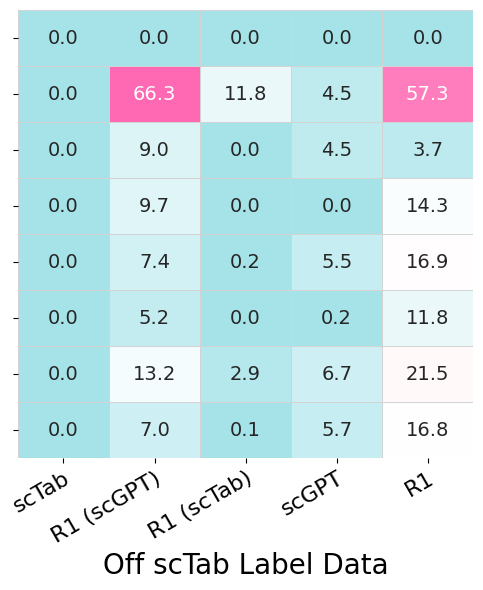

In [21]:
ax1 = plot_heatmap(
    tissue_f1.T,
    row_names=tissue_names,
    col_names=models,
    title="",
    xlabel="All Cells",
    ylabel="Macro F1 (%) for Datasets",
    cmap=my_cmap,      # Diverging colormap
    fmt=".1f",            # One decimal place
    figsize=(7.5, 6),       # Custom size
    xtick_rotation=30,
    vmin=0,
    vmax=0.5, annot_fontsize = 14
)
plt.show()

ax1 = plot_heatmap(
    f1_np_array_from_tissue_df(prediction_df_8d_in_sctab_by_tissue).T,
    row_names=['']*8,
    col_names=models,
    title="",
    xlabel="In scTab Label Data",
    ylabel="",
    cmap=my_cmap,      # Diverging colormap
    fmt=".1f",            # One decimal place
    figsize=(5, 6),       # Custom size
    xtick_rotation=30,
    vmin=0,
    vmax=0.6, annot_fontsize = 14
)
plt.show()

ax1 = plot_heatmap(
    f1_np_array_from_tissue_df(prediction_df_8d_off_sctab_by_tissue).T,
    row_names=['']*8,
    col_names=models,
    title="",
    xlabel="Off scTab Label Data",
    ylabel="",
    cmap=my_cmap,      # Diverging colormap
    fmt=".1f",            # One decimal place
    figsize=(5, 6),       # Custom size
    xtick_rotation=30,
    vmin=0,
    vmax=0.6, annot_fontsize = 14
)
plt.show()
# 1.25 3.87 4.84
# 1.25 5.42 4.84
# 1.25 6.42 4.84

# Off label balanced tissue OOD

In [22]:
# add in_scTab_label col
add_in_label(prediction_df_8d, str_list=sctab_split['matched'], name_col='ground_truth_label', new_col='in_scTab_label')
# remove metrics rows to keep cell rows only
df_8d = [df[:10000] for df in prediction_df_8d]

In [23]:
from functools import reduce
from openpyxl.utils import get_column_letter
from openpyxl import load_workbook
from typing import List

def merge_and_split_to_xlsx(
    df_list: List[pd.DataFrame],
    df_names: List[str],
    output_path: str,
    *,
    key_col: str = "cell",
    shared_cols: List[str] = ("in_scTab_label", "tissue", "ground_truth_label"),
    engine: str = "openpyxl",
) -> None:
    """
    Merge a list of DataFrames on *key_col*, keep exactly one copy of the columns
    in *shared_cols*, prefix every other column with the corresponding entry in
    *df_names*, and write an Excel workbook that contains one worksheet per
    tissue type.

    Parameters
    ----------
    df_list : list[pandas.DataFrame]
        Input DataFrames (identical schema before processing).
    df_names : list[str]
        Prefixes, in the same order as *df_list* (e.g. 
        ['scTab', 'R1_scGPT', 'R1_scTab', 'scGPT', 'R1']).
    output_path : str
        Full path, including “.xlsx”, where the workbook is written.
    key_col : str, default "cell"
        Column on which rows are aligned.
    shared_cols : list[str], default ("in_scTab_label", "tissue", "ground_truth_label")
        Columns that are identical across every DataFrame and should appear only
        once in the merged result (kept in the order provided).
    engine : str, default "openpyxl"
        Excel writer engine.

    Notes
    -----
    * Each DataFrame first renames the column ``match_scTab`` to ``match`` so
      the subsequent processing steps work on a unified schema.
    * Column widths in the final workbook are set so that every column is at
      least as wide as its header text (monospaced assumption).
    """
    if len(df_list) != len(df_names):
        raise ValueError("`df_list` and `df_names` must have the same length")

    processed: List[pd.DataFrame] = []

    # ------------------------------------------------------------------ #
    # 1‒ Prepare individual DataFrames                                   #
    # ------------------------------------------------------------------ #
    for idx, (prefix, df) in enumerate(zip(df_names, df_list)):
        df = df.copy()

        # Unify the column name for the match indicator.
        df.rename(columns={"match_scTab": "match"}, inplace=True, errors="ignore")

        # Add a prefix to every column that is *not* shared and not the key.
        cols_to_prefix = [
            c for c in df.columns if c not in shared_cols and c != key_col
        ]
        df.rename(columns={c: f"{prefix}_{c}" for c in cols_to_prefix}, inplace=True)

        # After prefixes are attached, remove shared columns from every DataFrame
        # except the first one to avoid duplicates in the merge.
        if idx > 0:
            df = df.drop(columns=[c for c in shared_cols if c in df.columns])

        processed.append(df)

    # ------------------------------------------------------------------ #
    # 2‒ Merge all DataFrames on the key (outer join)                     #
    # ------------------------------------------------------------------ #
    merged = reduce(
        lambda left, right: left.merge(right, on=key_col, how="outer"),
        processed,
    )

    # Place columns in the order: key ▸ shared ▸ everything else.
    first_cols = [key_col, *shared_cols]
    other_cols = [c for c in merged.columns if c not in first_cols]
    merged = merged[first_cols + other_cols]

    # ------------------------------------------------------------------ #
    # 3‒ Write one worksheet per tissue                                  #
    # ------------------------------------------------------------------ #
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    with pd.ExcelWriter(output_path, engine=engine) as writer:
        for tissue, sub_df in merged.groupby("tissue", dropna=False):
            # Create a safe sheet name (≤31 chars, no : \ / ? * [ ]).
            sheet_name = (
                str(tissue) if pd.notna(tissue) else "NA"
            )[:31].translate({ord(c): "_" for c in r':\/?*[]'})
            sub_df.to_excel(writer, sheet_name=sheet_name, index=False)

    # ------------------------------------------------------------------ #
    # 4‒ Auto-size columns                                               #
    # ------------------------------------------------------------------ #
    wb = load_workbook(output_path)
    for ws in wb.worksheets:
        for idx, cell in enumerate(ws[1], start=1):  # first row = headers
            header_len = len(str(cell.value or ""))
            ws.column_dimensions[get_column_letter(idx)].width = max(header_len + 2, 10)

    wb.save(output_path)
    print(f"Workbook saved to {output_path}")

In [24]:
# write the xlsx file for supplementary
prefixes = ['scTab', 'R1_scGPT', 'R1_scTab', 'scGPT', 'R1']
merge_and_split_to_xlsx(df_8d, prefixes, "/cristealab/xiwang/DSR1_Preprint/Outputs/supplementary_table/Supplementary_Table_S3.xlsx")

Workbook saved to /cristealab/xiwang/DSR1_Preprint/Outputs/supplementary_table/Supplementary_Table_S3.xlsx


In [25]:
# load the by-tissue excel file
# Path to the workbook you wrote earlier
xlsx_path = "/cristealab/xiwang/DSR1_Preprint/Outputs/supplementary_table/Supplementary_Table_S3.xlsx"

# Read every sheet into a dict of DataFrames.
#   • keys   = sheet names
#   • values = corresponding DataFrames
sheets = pd.read_excel(
    xlsx_path,
    sheet_name=None,        # None ⇒ read all sheets
    engine="openpyxl",      # same engine used to write
)
# remove missing in lung
for name, df in sheets.items():
    if name == 'lung':
        sheets[name] = df.dropna(subset=['ground_truth_label'])


In [26]:
# Example: iterate or access
for name, df in sheets.items():
    print(f"{name}: {df.shape}")

blood: (1250, 19)
breast: (1250, 19)
cerebellum: (1250, 19)
kidney: (1250, 19)
lung: (868, 19)
pancreas: (1250, 19)
peripheral region of retina: (1250, 19)
trachea: (1250, 19)


In [27]:
tissue_names = ['blood',
 'pancreas',
 'breast',
 'lung',
 'cerebellum',
 'trachea',
 'kidney',
 'peripheral region of retina']
prefixes   = ["scTab", "R1_scGPT", "R1_scTab", "scGPT", "R1"]
verdicts   = ['SAME_LABEL', 'PREDICTED_IS_CHILD_OF_GT', 'GT_IS_CHILD_OF_PREDICTED','NO_DIRECT_CHILD_RELATION']

# -------- 3. frequency -------- #
verdict_freqs = {}

for tissue in tissue_names:
    df = sheets[tissue]
    counts = np.zeros((len(prefixes), len(verdicts)), dtype=int)

    for i, prefix in enumerate(prefixes):
        col = f"{prefix}_verdict"
        # value_counts() 返回 Series；缺失值默认忽略
        vc = df[col].value_counts()

        for j, v in enumerate(verdicts):
            counts[i, j] = vc.get(v, 0)   # fill 0 if no value

    verdict_freqs[tissue] = counts

# -------- 4. output -------- #
for tissue, mat in verdict_freqs.items():
    print(f"\n{tissue} → shape {mat.shape}")
    print(mat)


blood → shape (5, 4)
[[125   7 877 241]
 [122 265 210 653]
 [188 266 228 568]
 [ 79  13 574 584]
 [155  74 252 769]]

pancreas → shape (5, 4)
[[  12    0  659  579]
 [1009    2   42  197]
 [ 105    7  783  355]
 [  29   13  810  398]
 [ 626    8   89  527]]

breast → shape (5, 4)
[[ 82  75 406 687]
 [292   3 388 567]
 [215   8 413 614]
 [ 80  53 283 834]
 [ 31   5 421 793]]

lung → shape (5, 4)
[[ 93  93 282 400]
 [ 45  72  11 740]
 [ 31  53  19 765]
 [ 28  42 232 566]
 [ 50  79  59 680]]

cerebellum → shape (5, 4)
[[ 24  28 518 680]
 [426  39  45 740]
 [ 32 101 473 644]
 [182 168 375 525]
 [473  50  24 703]]

trachea → shape (5, 4)
[[195 179 162 714]
 [ 68 221  62 899]
 [ 68 270  76 836]
 [116 150 209 775]
 [254  64 182 750]]

kidney → shape (5, 4)
[[425 176 230 419]
 [116 335 156 643]
 [219 226 165 640]
 [174 364  87 625]
 [313 229 111 597]]

peripheral region of retina → shape (5, 4)
[[503   0 237 510]
 [580  32 267 371]
 [494   1  59 696]
 [586   7 407 250]
 [183 116 157 794]]


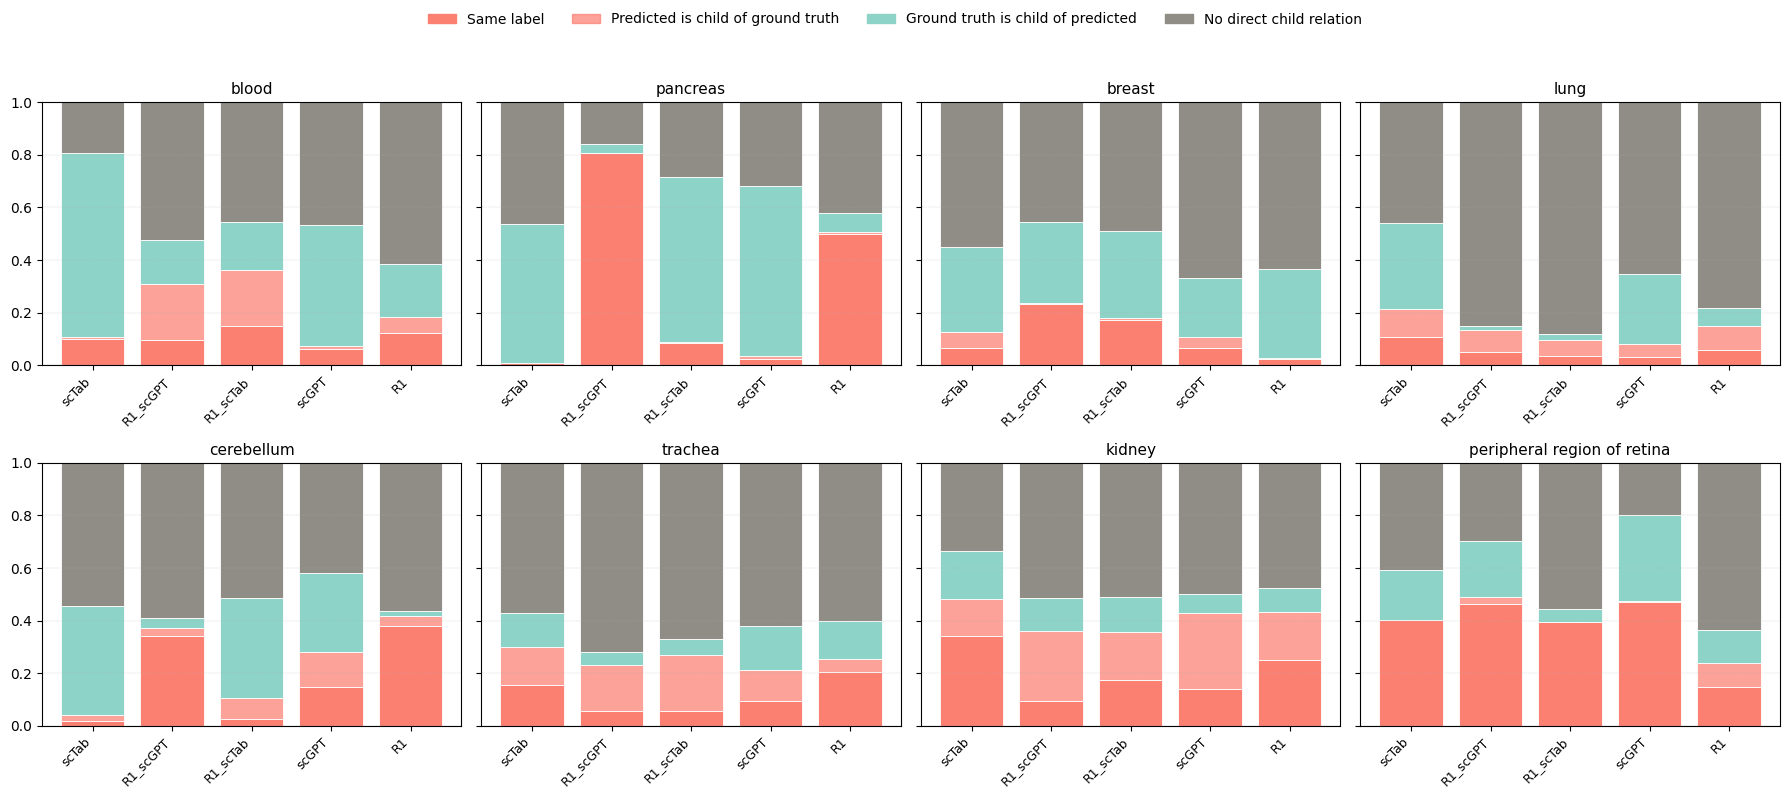

In [28]:
# ------------------------------------------------------------
# prerequisites (already prepared in previous steps)
# ------------------------------------------------------------
# verdict_freqs : dict[str, np.ndarray]   # {tissue: 5×4 frequency matrix}
# prefixes      : list[str]               # ['scTab', 'R1_scGPT', 'R1_scTab', 'scGPT', 'R1']
# verdicts      : list[str]               # verdict order the categories

# ------------------------------------------------------------
# plotting parameters
# ------------------------------------------------------------
n_rows, n_cols = 2, 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 8), sharey=True)
axes = axes.flatten()
colors         = ['#fb8072', "#fb8072ba", '#8dd3c7', 	"#908c86"]  # 4 colors

tissue_list = tissue_names

for ax, tissue in zip(axes, tissue_list):
    mat   = verdict_freqs[tissue]
    freqs = mat / mat.sum(axis=1, keepdims=True)

    bottom = np.zeros(len(prefixes))
    for v_lab, color in zip(verdicts, colors):
        ax.bar(
            x=np.arange(len(prefixes)),
            height=freqs[:, verdicts.index(v_lab)],
            bottom=bottom,
            color=color,
            edgecolor="white",
            linewidth=0.6,
        )
        bottom += freqs[:, verdicts.index(v_lab)]

    ax.set_xticks(range(len(prefixes)))
    ax.set_xticklabels(prefixes, rotation=45, ha="right", fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(tissue, fontsize=11)
    ax.grid(axis="y", linestyle="--", linewidth=0.3, alpha=0.6)

# hide unused axes if any
for ax in axes[len(tissue_list):]:
    ax.set_visible(False)

# single legend
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors]
fig.legend(
    handles,
    ['Same label', 'Predicted is child of ground truth', 'Ground truth is child of predicted','No direct child relation'],
    loc="upper center",
    ncol=len(verdicts),
    frameon=False,
    fontsize=10,
)

fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()
# 3.25 # 0.07 6.38

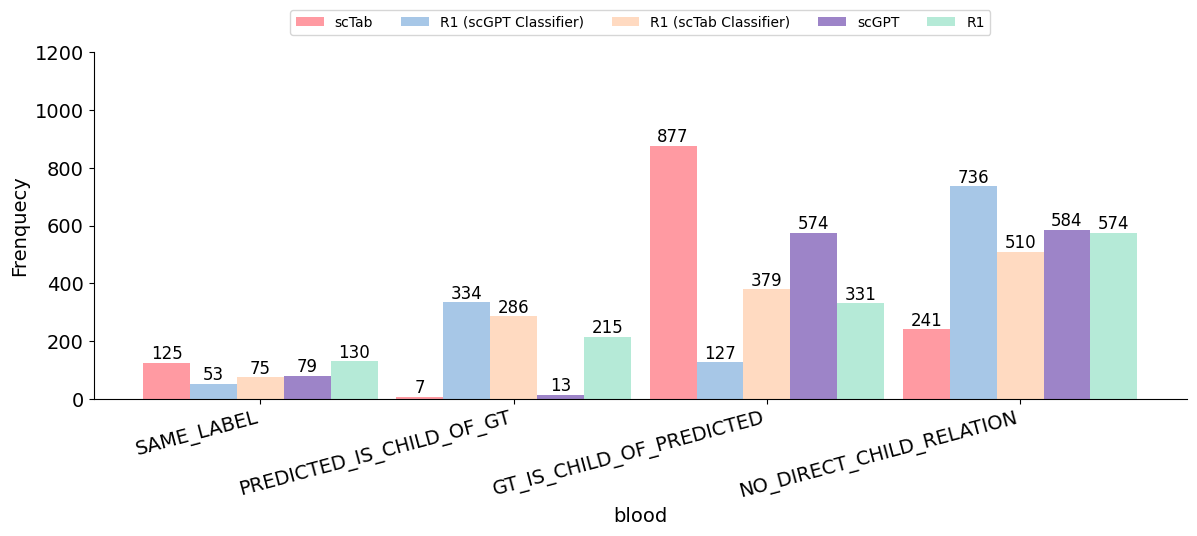

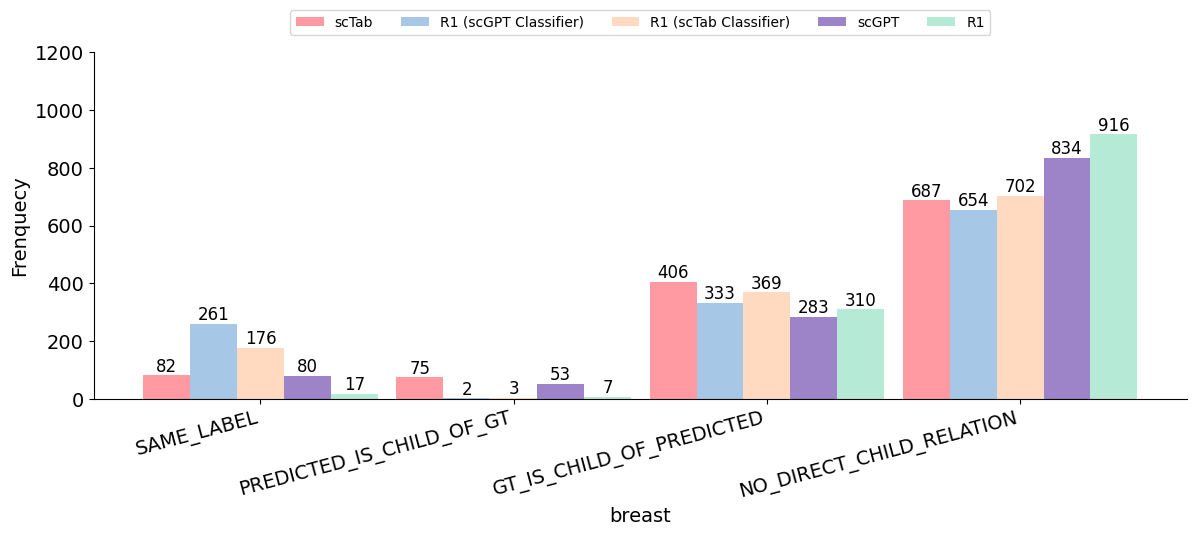

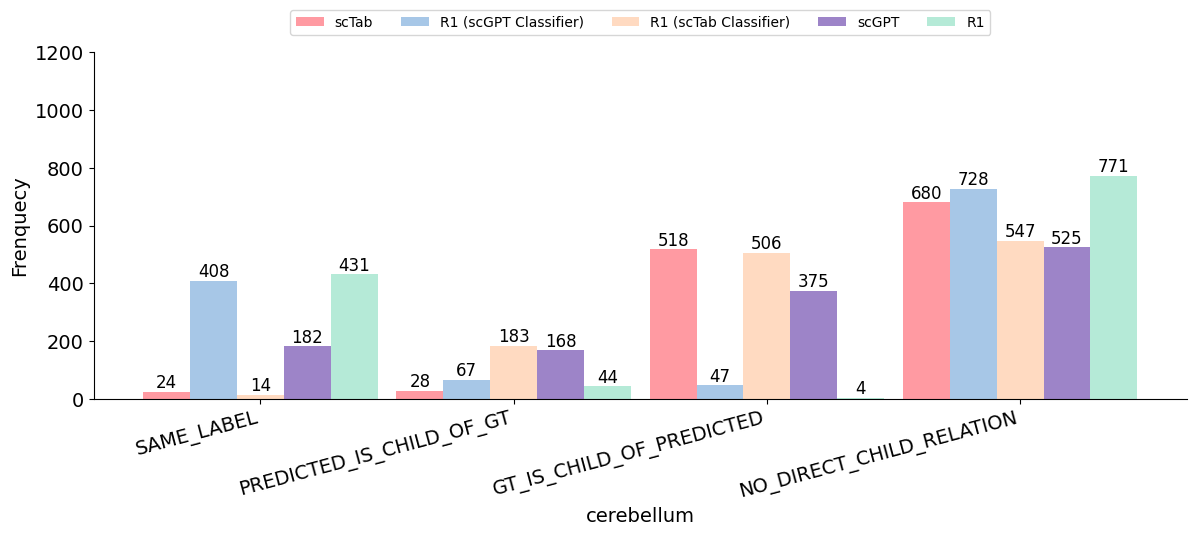

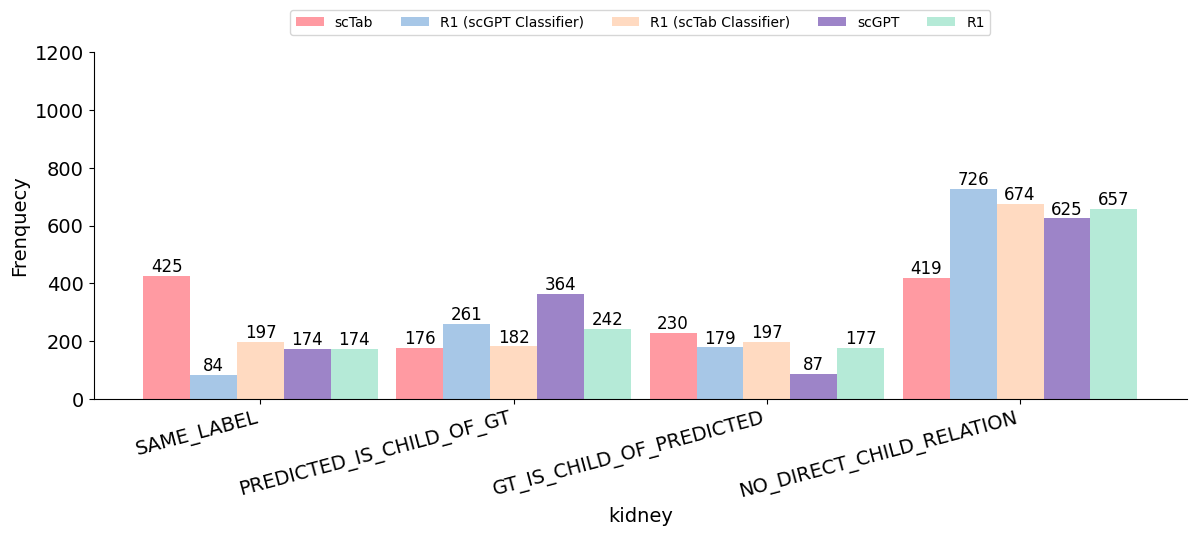

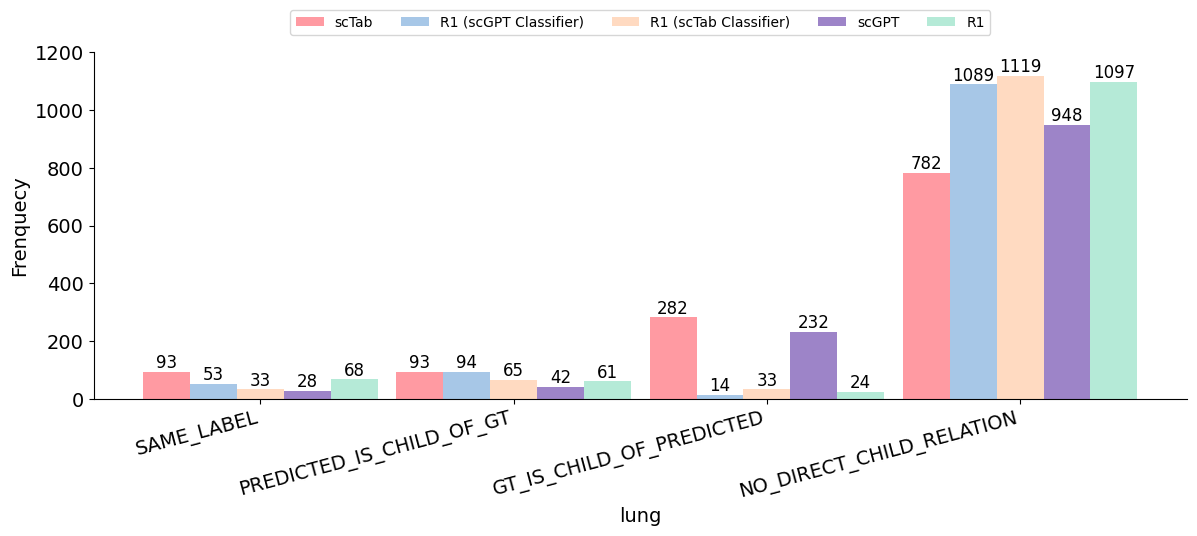

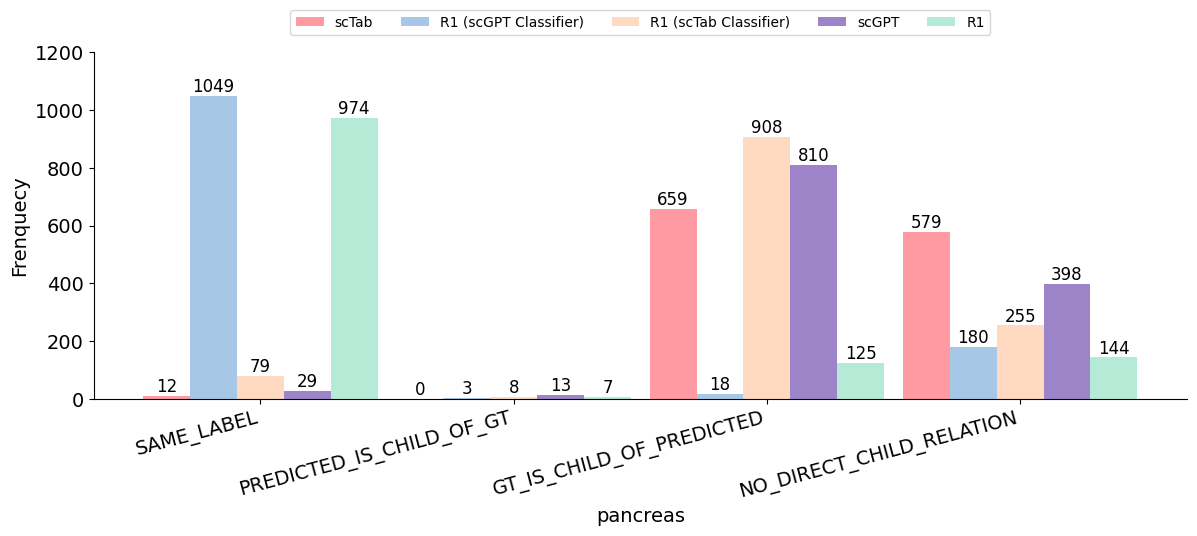

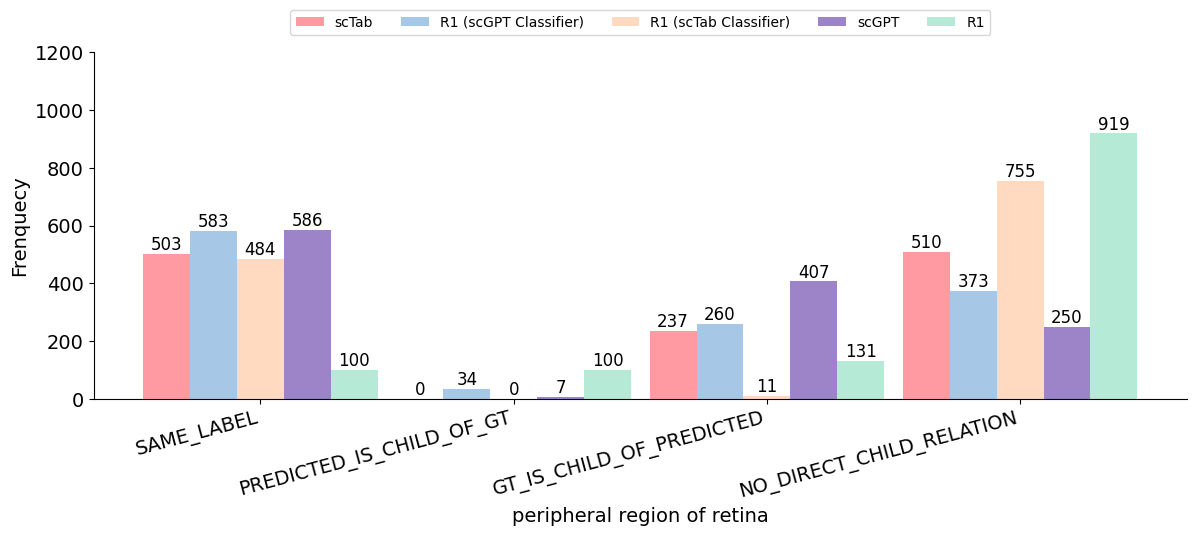

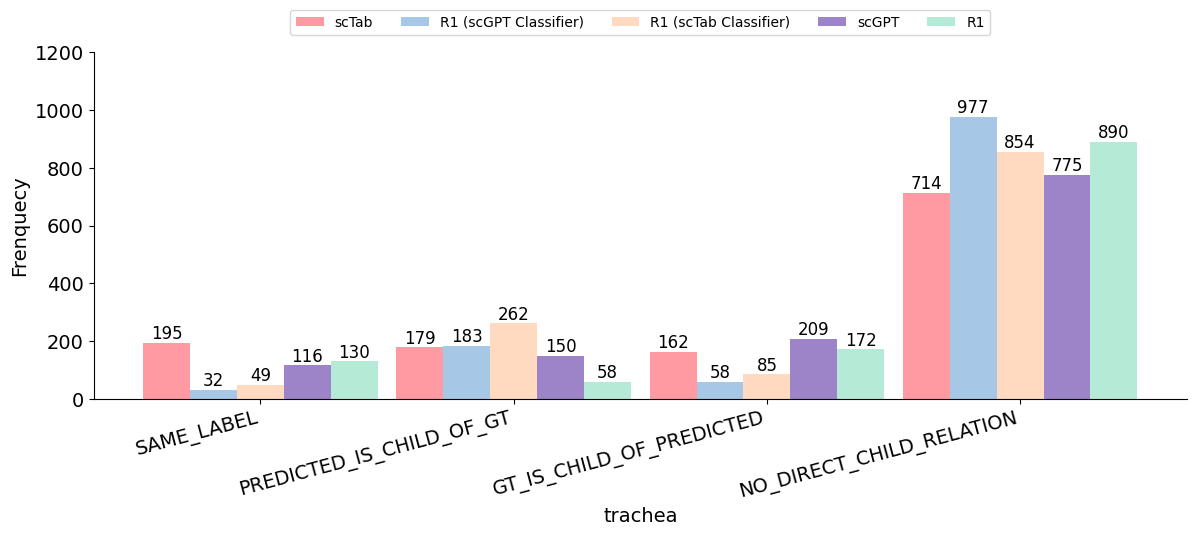

In [29]:
for tissue, mat in verdict_freqs.items():
    plotter = MetricPlotter(bar_width = 0.5, annotation_digits=0, 
                            percentage=False,
                            y_lim_lower = 0, 
                            y_lim_upper=1200
                            )
    plotter.display_axes_borders = 'xy'
    plotter.group_gap = 0.2
    plotter.text_margin = 0.001
    plotter.ncol_legend = 5
    plotter.colors = ['#FF9AA2','#A7C7E7','#FFDAC1','#9D84C8','#B5EAD7',]
    plotter.bar_fontsize = 12
    plotter.x_label_fontsize = 14
    plotter.y_label_fontsize=14
    plotter.x_tick_fontsize=14
    plotter.y_tick_fontsize=14
    plotter.rotation = 15
    groups = ['SAME_LABEL', 'PREDICTED_IS_CHILD_OF_GT', 'GT_IS_CHILD_OF_PREDICTED','NO_DIRECT_CHILD_RELATION']
    plotter.group_barplot(groups,models,metrics = mat, 
                x_label=tissue, y_label="Frenquecy", 
                # title="LLMs' Performance for Clusters"
                )

In [46]:
sctab_8d_matched = prediction_df_8d_by_sctab['matched'][0]
sctab_8d_unmatched = prediction_df_8d_by_sctab['unmatched'][0]
r1_sctab_8d_matched = prediction_df_8d_by_sctab['matched'][2]
r1_sctab_8d_unmatched = prediction_df_8d_by_sctab['unmatched'][2]

In [46]:
for df in prediction_df_8d_by_sctab['unmatched']:
    print(df.shape)

(4851, 6)
(4851, 6)
(4851, 6)
(4851, 6)
(4851, 6)


In [24]:
r1_sctab = prediction_df_8d[2]

In [47]:
from collections import Counter
Counter(r1_sctab_8d_unmatched['match_scTab'])

Counter({False: 4772, True: 79})

In [41]:
Counter(r1_sctab_8d_unmatched['tissue'])

Counter({'peripheral region of retina': 713,
         'blood': 1,
         'breast': 778,
         'lung': 372,
         'trachea': 518,
         'cerebellum': 926,
         'kidney': 312,
         'pancreas': 1231})

In [43]:
print(r1_sctab_8d_matched['match_scTab'].shape, r1_sctab_8d_matched['match_scTab'].shape)

(4761,) (4761,)


In [25]:
soma_id = [61717268,
 61936070,
 61969779,
 61241426,
 61745912,
 61740095,
 59598231,
 244619,
 244481,
 244360,
 244758,
 245520,
 244904,
 243883,
 244487,
 244676,
 245252,
 245070,
 243752,
 244116,
 245162,
 243837,
 244849,
 243787,
 244572,
 244858,
 245074,
 243772,
 244794,
 244821,
 244861,
 245566,
 244479,
 245045,
 244803,
 244785,
 243864,
 244247,
 244842,
 244495,
 245820,
 243736,
 243816,
 244555,
 244725,
 244956,
 245099,
 243786,
 245169,
 244584,
 244756,
 243884,
 244837,
 245197,
 244665,
 244846,
 245284,
 244471,
 244811,
 244637,
 245147,
 245052,
 243764,
 243726,
 243769,
 243876,
 245687,
 244929,
 244804,
 244627,
 243729,
 244527,
 245014,
 243735,
 245609,
 244642,
 244503,
 244890,
 243874,
 245275,
 244942,
 244880,
 243806,
 243869,
 244959,
 245226,
 244688,
 243866,
 245000,
 244605,
 244009,
 245088,
 243828,
 244965,
 244669,
 243712]

In [30]:
soma_id = [str(id) for id in soma_id]

In [27]:
match_id = [id for id in r1_sctab_8d_matched['cell']]
unmatch_id = [id for id in r1_sctab_8d_unmatched['cell']]

In [31]:
match_off_id = []
unmatch_off_id = []
for id in soma_id:
    if id in match_id: 
        match_off_id.append(id)
    else: 
        unmatch_off_id.append(id)
print(len(match_off_id), len(unmatch_off_id))

0 96


In [33]:
unmatch_off_df = r1_sctab_8d_unmatched[r1_sctab_8d_unmatched['cell'].isin(unmatch_off_id)]

In [34]:
unmatch_off_df

,cell,ground_truth_label,predicted_label,verdict,match_scTab,tissue
30,61717268,diffuse bipolar 1 cell,retina horizontal cell,NO_DIRECT_CHILD_RELATION,False,peripheral region of retina
588,61936070,glycinergic amacrine cell,retina horizontal cell,NO_DIRECT_CHILD_RELATION,False,peripheral region of retina
793,61969779,Mueller cell,retina horizontal cell,NO_DIRECT_CHILD_RELATION,False,peripheral region of retina
889,61241426,rod bipolar cell,retina horizontal cell,NO_DIRECT_CHILD_RELATION,False,peripheral region of retina
910,61745912,invaginating midget bipolar cell,retina horizontal cell,NO_DIRECT_CHILD_RELATION,False,peripheral region of retina
...,...,...,...,...,...,...
9990,244009,type B pancreatic cell,type B pancreatic cell,SAME_LABEL,True,pancreas
9991,245088,pancreatic acinar cell,pancreatic acinar cell,SAME_LABEL,True,pancreas
9993,243828,pancreatic acinar cell,pancreatic acinar cell,SAME_LABEL,True,pancreas
9995,244965,pancreatic acinar cell,pancreatic acinar cell,SAME_LABEL,True,pancreas


In [36]:
pancreas = r1_sctab[r1_sctab['tissue'].isin(['pancreas'])]

In [37]:
pancreas

,cell,ground_truth_label,predicted_label,verdict,match_scTab,tissue
8691,244795,pancreatic A cell,enteroendocrine cell,GT_IS_CHILD_OF_PREDICTED,False,pancreas
8706,243853,pancreatic A cell,enteroendocrine cell,GT_IS_CHILD_OF_PREDICTED,False,pancreas
8709,245658,pancreatic A cell,enteroendocrine cell,GT_IS_CHILD_OF_PREDICTED,False,pancreas
8715,245325,pancreatic A cell,enteroendocrine cell,GT_IS_CHILD_OF_PREDICTED,False,pancreas
8717,244266,pancreatic D cell,enteroendocrine cell,GT_IS_CHILD_OF_PREDICTED,False,pancreas
...,...,...,...,...,...,...
9995,244965,pancreatic acinar cell,pancreatic acinar cell,SAME_LABEL,True,pancreas
9996,245411,pancreatic ductal cell,epithelial cell of proximal tubule,NO_DIRECT_CHILD_RELATION,False,pancreas
9997,244669,pancreatic acinar cell,pancreatic acinar cell,SAME_LABEL,True,pancreas
9998,243758,pancreatic acinar cell,enterocyte,NO_DIRECT_CHILD_RELATION,False,pancreas


In [38]:
Counter(pancreas['ground_truth_label'])

Counter({'pancreatic A cell': 489,
         'pancreatic D cell': 104,
         'pancreatic ductal cell': 142,
         'pancreatic PP cell': 64,
         'type B pancreatic cell': 250,
         'endothelial cell': 13,
         'mesenchymal cell': 44,
         'pancreatic acinar cell': 138,
         'pancreatic endocrine cell': 5,
         'pancreatic epsilon cell': 1})

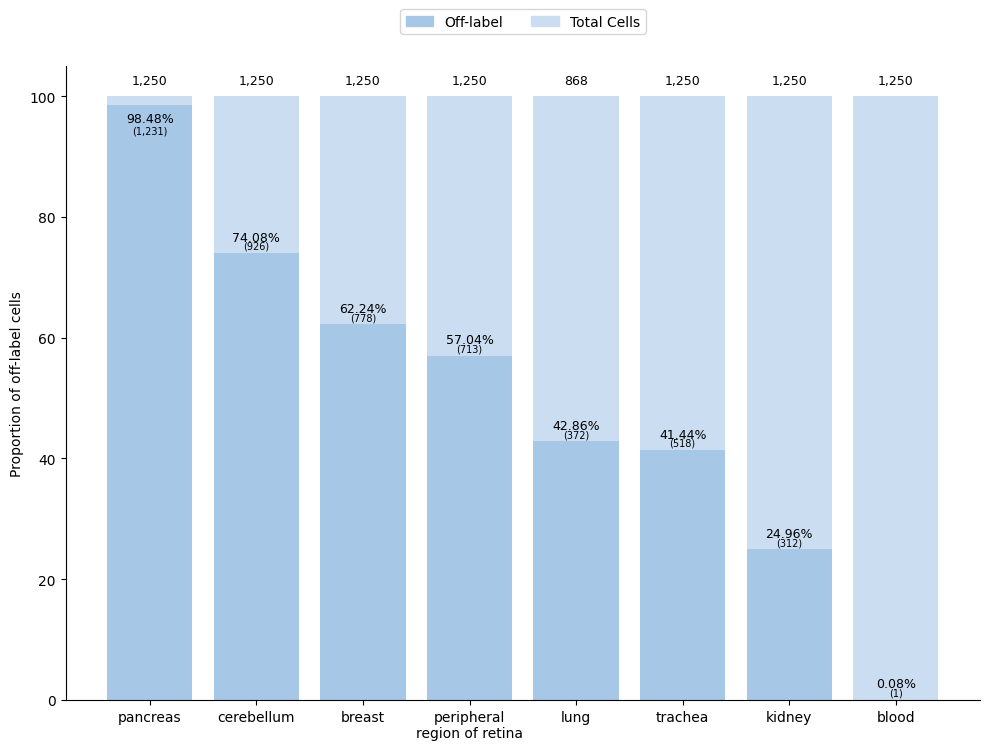

In [14]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
def lighten_color(color, amount=0.5):
    try:
        c = mcolors.to_rgb(color)
        c_white = mcolors.to_rgb('white')
        return tuple(c_val + (white_val - c_val) * amount for c_val, white_val in zip(c, c_white))
    except ValueError:
        print(f"Warning: Could not parse color '{color}'. Using gray.")
        try:
            c_gray = mcolors.to_rgb('gray')
            c_white = mcolors.to_rgb('white')
            return tuple(c_val + (white_val - c_val) * amount for c_val, white_val in zip(c_gray, c_white))
        except ValueError:
            return (0.7, 0.7, 0.7)
def plot_item_numbers_percent(
    items_names,
    numbers,
    colors = None,
    title: str = "",
    ylabel: str = "",
    display_border: bool = False,
    lighten_factor: float = 0.4,
    figsize = (10, 8),
    text_offset_factor: float = 0.015,
    legend_labels = ('Base', 'Incremental'),
    percentage_fontsize: int = 9,   # 大号
    numeric_fontsize: int = 7,      # 小号
    total_fontsize: int = 9,
    first_bar_low_score_num_downward_factor: float = 0.7,
    first_bar_perc_additional_downward_factor: float = 1.5,
    other_bars_perc_upward_offset_factor: float = 1.3,
    percentage_fmt: str = ".2f"
):
    num_items = len(items_names)
    if len(numbers) != num_items:
        raise ValueError("'items_names' 与 'numbers' 长度不同")

    if colors is None:
        default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
        colors = [default_colors[i % len(default_colors)] for i in range(num_items)]
    elif len(colors) != num_items:
        raise ValueError("'colors' 长度需和 'items_names' 一致")

    base_label, incremental_label = legend_labels
    x_pos = np.arange(num_items)
    text_offset = 100 * text_offset_factor
    legend_elements = {}

    fig, ax = plt.subplots(figsize=figsize)

    for i, (name, col, pair) in enumerate(zip(items_names, colors, numbers)):
        low_score, total = map(float, pair)
        if total <= 0:
            raise ValueError(f"'{name}' 的 total 必须 > 0")
        if low_score > total:  # 自动修正
            low_score, total = total, low_score

        pct_low = low_score / total * 100
        pct_inc = 100 - pct_low

        # --- 绘制条形 ---
        ax.bar(x_pos[i], pct_low, color=col)
        if base_label not in legend_elements:
            legend_elements[base_label] = mpatches.Patch(color=col, label=base_label)

        if pct_inc > 0:
            lighter_c = lighten_color(col, amount=lighten_factor)
            ax.bar(x_pos[i], pct_inc, bottom=pct_low, color=lighter_c)
            if incremental_label not in legend_elements:
                legend_elements[incremental_label] = mpatches.Patch(color=lighter_c, label=incremental_label)

        # --- 顶端总数 ---
        ax.text(
            x_pos[i],
            100 + text_offset,
            f"{int(total):,}",
            ha='center', va='bottom',
            fontsize=total_fontsize
        )

        # === 深色段两行文字（位置不变，只换内容与样式） ===
        # 1) 原 y_num_low (更靠上)
        if i == 0:
            y_num_low = pct_low - text_offset * first_bar_low_score_num_downward_factor
            va_num_low = 'top'
            if y_num_low < 0 and pct_low > 0:
                y_num_low = text_offset * 0.1
        else:
            y_num_low = pct_low + text_offset
            va_num_low = 'bottom'

        # 2) 原 y_perc (更靠下)
        if i == 0:
            y_perc = y_num_low - text_offset * first_bar_perc_additional_downward_factor
            va_perc = 'top'
            if y_perc < 0:
                y_perc = text_offset * 0.05 if y_num_low >= text_offset * 0.1 else y_num_low
        else:
            y_perc = pct_low + text_offset * other_bars_perc_upward_offset_factor
            va_perc = 'top'   # 关键修改：用 'top' 让小号文字向下展开

        # -- 写百分比（大号） --
        ax.text(
            x_pos[i],
            y_num_low,
            f"{pct_low:{percentage_fmt}}%",
            ha='center', va=va_num_low,
            fontsize=percentage_fontsize
        )

        # -- 写绝对数（小号，括号） --
        ax.text(
            x_pos[i],
            y_perc,
            f"({int(low_score):,})",
            ha='center', va=va_perc,
            fontsize=numeric_fontsize
        )

    # --- 轴 & 边框 ---
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(items_names, rotation=0)
    ax.set_ylim(0, 105)
    ax.set_yticks(np.linspace(0, 100, 6))

    if not display_border:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    if legend_elements:
        ax.legend(
            handles=list(legend_elements.values()),
            bbox_to_anchor=(0.5, 1.05),
            loc='lower center',
            borderaxespad=0.,
            ncol=len(legend_elements)
        )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


plot_item_numbers_percent(
    items_names=['pancreas','cerebellum','breast','peripheral\nregion of retina',
                 'lung','trachea','kidney','blood'],
    numbers=[[1231, 1250],[926,1250],[778,1250],[713,1250],
             [372,868],[518,1250],[312,1250],[1,1250]],
    colors=['#A7C7E7']*8,
    title="",
    ylabel = "Proportion of off-label cells",
    legend_labels=('Off-label', 'Total Cells')
)


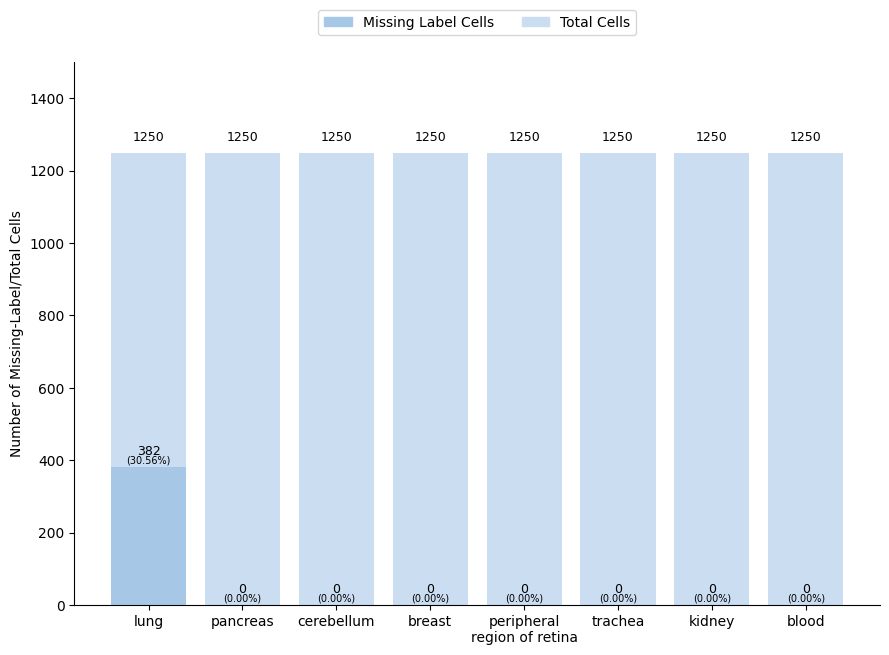

In [22]:
from typing import List, Union, Tuple, Optional

def plot_item_numbers(
    items_names: List[str],
    numbers: List[Union[float, Tuple[float, float]]],
    colors: Optional[List[str]] = None,
    title: str = "",
    ylabel: str = "",
    display_border: bool = True,
    lighten_factor: float = 0.4,
    figsize: Tuple[int, int] = (10, 6),
    text_offset_factor: float = 0.015, # General offset for text above bars
    legend_labels: Union[Tuple[str, str], str] = ('Base', 'Incremental'),
    single_score_label_override: Optional[str] = None,
    first_bar_low_score_num_downward_factor: float = 0.75, # How much first bar's low_score NUMERIC text is shifted down (rel to text_offset)
    first_bar_perc_additional_downward_factor: float = 1.5, # *Additional* downward shift for first bar's PERCENTAGE text (rel to text_offset), from numeric text's new pos
    other_bars_perc_upward_offset_factor: float = 0.5, # How much other bars' PERCENTAGE text is shifted *up* (rel to text_offset) from low_score line
    show_percentage: bool = True,
    percentage_fontsize: int = 8
):
    num_items = len(items_names)
    if len(numbers) != num_items:
        raise ValueError("Length of 'items_names' and 'numbers' must be the same.")

    if colors is None:
        prop_cycle = plt.rcParams['axes.prop_cycle']
        default_colors = prop_cycle.by_key()['color']
        colors = [default_colors[i % len(default_colors)] for i in range(num_items)]
    elif len(colors) != num_items:
        raise ValueError("Length of 'colors' must match 'items_names' if provided.")

    if isinstance(legend_labels, tuple) and len(legend_labels) == 2:
        base_label, incremental_label = legend_labels
        single_label = single_score_label_override if single_score_label_override is not None else incremental_label
    elif isinstance(legend_labels, str):
        base_label = "Base (default)"
        incremental_label = "Incremental (default)"
        single_label = single_score_label_override if single_score_label_override is not None else legend_labels
    else:
        raise ValueError("legend_labels must be a tuple of two strings or a single string.")

    x_pos = np.arange(num_items)
    max_score = 0
    legend_elements = {}

    plt.figure(figsize=figsize)
    ax = plt.gca()

    for i_val_check in range(num_items):
        score_check = numbers[i_val_check]
        current_max_val = 0
        if isinstance(score_check, (tuple, list)):
            current_max_val = score_check[1] if len(score_check) > 1 else (score_check[0] if len(score_check) > 0 else 0)
        else:
            current_max_val = float(score_check)
        if isinstance(current_max_val, (int, float)) and current_max_val > max_score:
            max_score = current_max_val
    
    text_offset = max_score * text_offset_factor if max_score > 0 else 0.01

    for i in range(num_items):
        score_val = numbers[i]
        color = colors[i]

        if isinstance(score_val, (tuple, list)) and len(score_val) == 2:
            low_score, high_score = score_val
            if not (isinstance(low_score, (int, float)) and isinstance(high_score, (int, float))):
                print(f"Warning: Item '{items_names[i]}' has non-numeric scores. Skipping text. Values: {low_score}, {high_score}")
                continue

            if low_score > high_score:
                low_score, high_score = high_score, low_score
            if low_score < 0 or high_score < 0:
                print(f"Warning: Item '{items_names[i]}' has negative numbers.")

            # Plot bars
            bar1 = ax.bar(x_pos[i], low_score, color=color)
            if base_label not in legend_elements:
                legend_elements[base_label] = mpatches.Patch(color=color, label=base_label)

            if high_score > low_score:
                lighter_c = lighten_color(color, amount=lighten_factor)
                bar2 = ax.bar(x_pos[i], high_score - low_score, bottom=low_score, color=lighter_c)
                if incremental_label not in legend_elements:
                    legend_elements[incremental_label] = mpatches.Patch(color=lighter_c, label=incremental_label)
            
            # --- Text for low_score (numeric value) ---
            y_num_low_score: float
            va_num_low_score: str
            
            if i < 0: #(for bars that are specific)
                y_num_low_score = low_score - (text_offset * first_bar_low_score_num_downward_factor)
                va_num_low_score = 'top'
                if y_num_low_score < 0 and low_score > 0: y_num_low_score = text_offset * 0.1 
                elif low_score == 0 and y_num_low_score < (text_offset * 0.1): y_num_low_score = text_offset * 0.1
            else:
                y_num_low_score = low_score + text_offset # Numeric value above its bar segment
                va_num_low_score = 'bottom'
            
            if low_score >= 0:
                ax.text(x_pos[i], y_num_low_score, f"{low_score:g}", 
                        ha='center', va=va_num_low_score, fontsize=9)

            # --- Text for percentage of low_score relative to high_score ---
            if show_percentage and high_score > 0 and low_score >= 0:
                percentage_val = (low_score / high_score) * 100
                perc_str = f"({percentage_val:.2f}%)" # MODIFIED: .2f for two decimal places
                
                y_perc: float
                va_perc: str
                
                if i == 0: 
                    # Percentage text below the (already lowered) numeric text for the first bar
                    y_perc = low_score + (text_offset * other_bars_perc_upward_offset_factor)
                    va_perc = 'bottom'
                    if y_perc < 0 : # Prevent perc text going too low
                        y_perc = text_offset * 0.05 if y_num_low_score >= (text_offset * 0.1) else y_num_low_score
                else: 
                    # For other bars: percentage text also above its bar segment,
                    # but slightly less offset than the numeric text, or positioned relative to it.
                    # Option 1: Place it slightly below the numeric text (which is at y_num_low_score, va='bottom')
                    # y_perc = y_num_low_score - (text_offset * 0.5) # Adjust 0.5 for spacing
                    # va_perc = 'bottom' 
                    # Option 2: Place it above the bar segment, but with its own offset (potentially smaller than numeric text)
                    y_perc = low_score + (text_offset * other_bars_perc_upward_offset_factor)
                    va_perc = 'bottom' # Aligns bottom of text with y_perc

                ax.text(x_pos[i], y_perc, perc_str,
                        ha='center', va=va_perc, fontsize=percentage_fontsize)

            # Text for high_score
            if high_score >=0:
                ax.text(x_pos[i], high_score + text_offset, f"{high_score:g}", 
                        ha='center', va='bottom', fontsize=9)

        else: # Single score
            single_score = float(score_val)
            if single_score < 0:
                print(f"Warning: Item '{items_names[i]}' has negative score.")

            bar_single = ax.bar(x_pos[i], single_score, color=color)
            if single_label not in legend_elements:
                legend_elements[single_label] = mpatches.Patch(color=color, label=single_label)
            
            if single_score >=0:
                ax.text(x_pos[i], single_score + text_offset, f"{single_score:g}", 
                        ha='center', va='bottom', fontsize=9)

    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(items_names, rotation=0)
    ax.set_ylim(bottom=0, top=max_score * 1.20 if max_score > 0 else 1)

    if not display_border:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    if legend_elements:
        ax.legend(handles=list(legend_elements.values()),
                  bbox_to_anchor=(0.5, 1.05),
                  loc='lower center',
                  borderaxespad=0.,
                  ncol=len(legend_elements))

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
# Data
plot_item_numbers(
    items_names=['lung', 'pancreas', 'cerebellum', 'breast', 'peripheral\nregion of retina','trachea', 'kidney', 'blood'],
    numbers=[[382, 1250]]+[[0, 1250]]*7,
    colors=['#A7C7E7']*8,
    title="",
    ylabel="Number of Missing-Label/Total Cells",
    figsize=(9, 7), # Increased height a bit more for text spacing
    display_border=False,
    legend_labels=('Missing Label Cells', 'Total Cells'),
    single_score_label_override='Single Score Type',
    text_offset_factor=0.02, # General offset, maybe increase slightly if text is still cramped
    first_bar_low_score_num_downward_factor=0.8, # e.g., 0.8 * text_offset below low_score line
    first_bar_perc_additional_downward_factor=1.8, # e.g., 1.8 * text_offset below THE NUMERIC TEXT'S NEW POSITION. Needs to be larger.
    other_bars_perc_upward_offset_factor=0.15, # e.g., 0.3 * text_offset above low_score line. Should be < 1.0 (factor for numeric text)
                                              # to be below the numeric text.
    show_percentage=True,
    percentage_fontsize=7 # Made slightly smaller to help with spacing
)

In [9]:
# for random ood r1 with scTab classifier
soma = [str(i) for i in [1974439, 33045237, 11114344, 33033201, 5630771, 19231696, 15761036, 961335, 5643469, 27213530, 33213878, 22428086, 698885, 61865366, 22380772, 33138528, 1974648, 22378612, 32968588, 33111977, 22332050, 22372140, 5663503, 31689012, 32978529, 14021111, 22376868, 11113679, 61641922, 19279471, 5627793, 7984453, 33046543, 15677213, 31652422, 22345246, 59351043, 15606133, 33159288, 15606716, 22335431, 33106057, 19305461, 33011239, 15692356, 22424801, 15679761, 15652405, 31741857, 14044685, 5665000, 62195412, 31785945, 22329220, 5644745, 5662656, 59181619, 33049054, 19272150, 19340649, 32999859, 22327164, 4459095, 11078488, 33141343, 560682, 33113023, 32967511, 19255845, 15605913, 22341486, 22415581, 19282531, 19250409, 15651119, 33095033, 61728166, 5664781, 31730758, 5643059, 11107749, 4478653, 19215016, 19349722, 19265008, 61841791, 7980937, 5634437, 15614564, 59579255, 59236894, 640441, 19208828, 19220325, 22324548, 32998986, 61910069, 19357909, 5657597, 61525917, 33139035, 19279285, 61757492, 22384758, 22398594, 33101823, 5652315, 22378885, 33033385, 22325065, 33043060, 22343824, 59183698, 22345536, 33208360, 22369093, 11108873, 5655260, 15759564, 19353121, 59511958, 59181620, 12536064, 22382825, 5625724, 33184079, 19345498, 33112349, 22426882, 33181153, 19254053, 15604379, 33135772, 33154044, 5636521, 22364735, 31768415, 33171764, 22412240, 32968486, 22365820, 19257982, 7497831, 33092089, 33194061, 19341716, 22367854, 33102788, 31771557, 559504, 11092698, 19266385, 5631457, 59481499, 19325167, 33180992, 5628317, 33085853, 22351260, 19296710, 32949509, 32947853, 61439700, 62138991, 22387190, 33177690, 22327801, 33017668, 19325582, 22426609, 33048111, 32947153, 19261163, 22362574, 5620105, 19275511, 19258828, 59485347, 62186683, 5647960, 33030976, 955059, 31793833, 22362396, 22381648, 33114647, 62050734, 4467100, 19261108, 966563, 22333419, 19210308, 62064594, 1973820, 14022858, 15696990, 33093112, 5664653, 5623074, 5655273, 5632675, 33143876, 19211508, 33101136, 33162846, 33097500, 31746563, 22408742, 5624288, 33075260, 19303163, 22339213, 5665212, 5632854, 33002022, 703049, 22320320, 11101978, 33042280, 19246164, 22396573, 19211392, 19319494, 19364806, 5662321, 22336943, 5664858, 19331712, 19265914, 33104118, 22351744, 19343902, 5630796, 22372637, 33003034, 33201256, 5650081, 19293120, 15726768, 5628406, 15674878, 22330319, 32964296, 5641777, 19280295, 22377819, 19340376, 22413859, 33183728, 969774, 22396734, 33075089, 33196854, 33083790, 31709588, 11108462, 22322677, 22375073, 59184933, 19350148, 33096686, 7990394, 15685880, 11030718, 19284080, 33081815, 22423691, 5645258, 33001418, 22412788, 5638816, 33101915, 22348061, 22414403, 15727308, 19345987, 33167780, 11099484, 22369295, 59208365, 33003388, 19291397, 5625021, 15756520, 5641834, 33198609, 59300791, 32977529, 22373614, 22407501, 11108865, 22325441, 22361537, 19353270, 15737051, 15758341, 19269278, 33154144, 33071527, 31652481, 22411629, 22422989, 19319351, 19295191, 956104, 59469498, 59588451, 61938648, 5640967, 33165155, 61283386, 19338690, 19346788, 15617640, 22382593, 59270217, 1844584, 5659978, 786034, 22324953, 62799135, 11129200, 703417, 33155903, 31664393, 12508964, 19247965, 31692959, 59416499, 639136, 22408643, 15678723, 22379978, 19279099, 8010994, 3783344, 33035009, 7997270, 22323633, 22378628, 960811, 5634317, 22348532, 11091820, 968508, 59337797, 22326319, 11064663, 646501, 11099691, 19321740, 5623168, 22379989, 33194066, 19283769, 561390, 22421154, 19264146, 31688925, 639026, 22416526, 5655565, 59596033, 15755991, 61359989, 5659919, 32995539, 31647215, 12575661, 33196411, 1976334, 22406183, 5632302, 19298521, 5661449, 33093698, 22396600, 5623364, 19324826]]
off_prediction = r1_sctab_cls_random[r1_sctab_cls_random['cell'].isin(soma)]

In [12]:
sum(off_prediction['match_scTab'])

81

In [18]:
off_prediction

,cell,ground_truth_label,predicted_label,verdict,match_scTab
21,1974439,stromal cell,fibroblast,PREDICTED_IS_CHILD_OF_GT,True
28,33045237,stromal cell,fibroblast,PREDICTED_IS_CHILD_OF_GT,True
29,11114344,plasma cell,fibroblast,NO_DIRECT_CHILD_RELATION,False
57,33033201,stromal cell,fibroblast,PREDICTED_IS_CHILD_OF_GT,True
109,5630771,periportal region hepatocyte,hepatocyte,GT_IS_CHILD_OF_PREDICTED,False
...,...,...,...,...,...
9831,5661449,periportal region hepatocyte,hepatocyte,GT_IS_CHILD_OF_PREDICTED,False
9896,33093698,stromal cell,intestinal lamina propria fibroblast,PREDICTED_IS_CHILD_OF_GT,True
9925,22396600,skin fibroblast,fibroblast,GT_IS_CHILD_OF_PREDICTED,False
9927,5623364,centrilobular region hepatocyte,hepatocyte,GT_IS_CHILD_OF_PREDICTED,False


In [17]:
Counter(off_prediction['verdict'])

Counter({'PREDICTED_IS_CHILD_OF_GT': 51,
         'NO_DIRECT_CHILD_RELATION': 110,
         'GT_IS_CHILD_OF_PREDICTED': 188,
         'SAME_LABEL': 30})

In [14]:
# for random ood r1 with scgpt classifier
soma_scgpt = [str(i) for i in [19342850, 12464241, 19247255, 14001581, 32968793, 29872567, 12521848, 12526746, 59213324, 59505846, 29579395, 14000836, 19305461, 13941578, 22628315, 12528009, 24683654, 19282531, 12480356, 23111909, 22634598, 19210846, 19277944, 19279984, 59352899, 22653343, 59141589, 25405356, 12491625, 59513085, 59342359, 19275511, 59505228, 19258462, 12526139, 59197810, 73593114, 12479451, 32030305, 13941465, 11113757, 19275035, 29872037, 8028533, 12521345, 23143875, 7984626, 12526792, 61392077, 12542005, 29575314, 29656379, 12466592, 12508964, 12465154, 29568138, 12467676, 29643136, 59416163, 7986324, 12480226, 12575661, 19324826]]
off_prediction_scgpt = r1_scgpt_cls_random[r1_scgpt_cls_random['cell'].isin(soma_scgpt)]
sum(off_prediction_scgpt['match_scTab'])

15

In [16]:
Counter(off_prediction_scgpt['verdict'])

Counter({'NO_DIRECT_CHILD_RELATION': 36,
         'GT_IS_CHILD_OF_PREDICTED': 12,
         'PREDICTED_IS_CHILD_OF_GT': 11,
         'SAME_LABEL': 4})

In [19]:
off_prediction_scgpt

,cell,ground_truth_label,predicted_label,verdict,match_scTab
141,19342850,T cell,adipocyte,NO_DIRECT_CHILD_RELATION,False
263,12464241,adipocyte of breast,adipocyte,GT_IS_CHILD_OF_PREDICTED,False
337,19247255,endothelial cell,adipocyte,NO_DIRECT_CHILD_RELATION,False
432,14001581,neuron,dopaminergic neuron,PREDICTED_IS_CHILD_OF_GT,True
486,32968793,placental villous trophoblast,placental villous trophoblast,SAME_LABEL,True
...,...,...,...,...,...
9210,59416163,endothelial tip cell,adipocyte,NO_DIRECT_CHILD_RELATION,False
9283,7986324,vascular lymphangioblast,adipocyte,NO_DIRECT_CHILD_RELATION,False
9450,12480226,endothelial cell of vascular tree,adipocyte,NO_DIRECT_CHILD_RELATION,False
9717,12575661,adipocyte of breast,adipocyte,GT_IS_CHILD_OF_PREDICTED,False
